<a href="https://colab.research.google.com/github/sfaril12/E1E124049_SafarilAdam_MachineLearning/blob/main/Clustering_Safaril_Adam_E1E124049l.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Judul Proyek**
**Analisis Clustering Negara Berdasarkan Risiko Kesehatan (SDGs 3)**
Proyek ini menggunakan teknik pembelajaran mesin tidak diawasi (*unsupervised learning*) untuk mengidentifikasi profil kesehatan negara-negara di dunia.

### **2. Latar Belakang**
*   **SDGs 3 (Sustainable Development Goals):** Memastikan kehidupan yang sehat dan mendukung kesejahteraan bagi semua usia.
*   **Pentingnya Pengelompokkan:** Dengan mengelompokkan negara berdasarkan indikator kesehatan (seperti angka kematian, penyakit menular, dan faktor ekonomi). Dengan hal ini, organisasi internasional atau pemerintah dapat:
    *   Menentukan prioritas distribusi bantuan kesehatan global.
    *   Mengidentifikasi negara-negara yang membutuhkan intervensi mendesak pada isu spesifik (misal: HIV/AIDS atau cakupan vaksinasi).
    *   Belajar dari negara di klaster yang sama yang memiliki performa lebih baik.


### **Tujuan Penelitian**
Penelitian ini dirancang dengan tujuan utama sebagai berikut:

1.  **Identifikasi Profil Risiko:** Mengelompokkan negara-negara di dunia ke dalam klaster berdasarkan indikator kesehatan struktural (seperti angka harapan hidup, mortalitas, dan cakupan imunisasi).
2.  **Prioritas Intervensi Global:** Memberikan basis data bagi organisasi internasional untuk menentukan negara mana yang memerlukan bantuan mendesak dalam mencapai target **SDG 3** (Kehidupan Sehat dan Sejahtera).
3.  **Analisis Faktor Kunci:** Mengidentifikasi fitur kesehatan atau ekonomi apa yang paling berpengaruh dalam memisahkan profil kesehatan antar negara melalui teknik reduksi dimensi (PCA).
4.  **Evaluasi Model Clustering:** Membandingkan efektivitas berbagai algoritma pembelajaran mesin (*K-Means, Hierarchical, DBSCAN*) dalam menangkap pola distribusi kesehatan global.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import skew
import pickle
import warnings
warnings.filterwarnings('ignore')

# The file will now be read directly from a URL, so file upload is not needed.
# from google.colab import files
# print("Silakan upload file 'Life Expectancy Data.csv'...")
# uploaded = files.upload()

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("\n[OK] Library berhasil dimuat!")


[OK] Library berhasil dimuat!


In [ ]:
print("=" * 70)
print("BAGIAN 1: LOADING & EKSPLORASI DATA")
print("=" * 70)

# Mengubah agar membaca file dari URL raw GitHub
# Perhatian: Pastikan URL ini adalah link langsung ke file CSV di GitHub.
github_csv_url = 'https://raw.githubusercontent.com/sfaril12/dataset-machine-learning/refs/heads/main/Life%20Expectancy%20Data.csv'
df = pd.read_csv(github_csv_url)
print(f"\nUkuran dataset  : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Jumlah negara   : {df['Country'].nunique()}")
print(f"Rentang tahun   : {df['Year'].min()} - {df['Year'].max()}")
print(f"\nStatus negara:\n{df['Status'].value_counts()}")

print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_info[missing_info['Missing'] > 0].sort_values('Missing', ascending=False))

df.head()

BAGIAN 1: LOADING & EKSPLORASI DATA

Ukuran dataset  : 2938 baris x 22 kolom
Jumlah negara   : 193
Rentang tahun   : 2000 - 2015

Status negara:
Status
Developing    2426
Developed      512
Name: count, dtype: int64

--- Missing Values ---
                                 Missing  Persen (%)
Population                           652       22.19
Hepatitis B                          553       18.82
GDP                                  448       15.25
Total expenditure                    226        7.69
Alcohol                              194        6.60
Income composition of resources      167        5.68
Schooling                            163        5.55
 thinness 5-9 years                   34        1.16
 thinness  1-19 years                 34        1.16
 BMI                                  34        1.16
Polio                                 19        0.65
Diphtheria                            19        0.65
Life expectancy                       10        0.34
Adult Mortality   

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### **3. Sumber Data & Detail Fitur**
*   **Dataset:** *Life Expectancy (WHO)*.
*   **Rentang Waktu:** 2000 - 2015 (16 tahun).
*   **Cakupan:** 193 negara dengan 22 fitur awal.

#### **A. Fitur yang Digunakan (14 Fitur)**
Fitur-fitur ini dipilih karena memiliki korelasi langsung dengan indikator kesehatan SDGs 3 dan beban penyakit:
1.  **Life expectancy**: Angka harapan hidup rata-rata.
2.  **Adult Mortality**: Probabilitas kematian antara usia 15-60 tahun per 1000 penduduk.
3.  **infant deaths**: Jumlah kematian bayi per 1000 penduduk.
4.  **under-five deaths**: Jumlah kematian balita per 1000 penduduk.
5.  **HIV/AIDS**: Kematian per 1000 kelahiran hidup akibat HIV/AIDS (usia 0-4 tahun).
6.  **Measles**: Jumlah kasus Campak yang dilaporkan per 1000 penduduk.
7.  **BMI**: Rata-rata Body Mass Index seluruh penduduk.
8.  **Polio**: Cakupan imunisasi Polio (Pol3) di antara anak usia 1 tahun.
9.  **Diphtheria**: Cakupan imunisasi Difteri, Pertusis, dan Tetanus (DTP3) usia 1 tahun.
10. **Hepatitis B**: Cakupan imunisasi Hepatitis B (HepB) usia 1 tahun.
11. **thinness 1-19 years**: Prevalensi kekurusan pada anak dan remaja usia 1-19 tahun.
12. **GDP**: Gross Domestic Product per kapita (dalam USD).
13. **Income composition of resources**: Indeks Pembangunan Manusia dalam hal komposisi pendapatan sumber daya (skala 0-1).
14. **Schooling**: Rata-rata jumlah tahun sekolah.

#### **B. Fitur yang Tidak Digunakan (8 Fitur)**
Fitur ini dikeluarkan untuk menjaga fokus pada clustering risiko kesehatan atau karena redundansi:
1.  **Country**: Digunakan sebagai indeks/label (bukan fitur numerik).
2.  **Year**: Data diagregasi (rata-rata), sehingga dimensi waktu tidak lagi digunakan sebagai fitur individu.
3.  **Status**: Label kategorikal (Developed/Developing), tidak digunakan agar clustering murni berdasarkan data performa kesehatan.
4.  **Alcohol**: Konsumsi alkohol per kapita.
5.  **percentage expenditure**: Pengeluaran kesehatan sebagai persentase dari GDP per kapita.
6.  **Total expenditure**: Pengeluaran pemerintah untuk kesehatan sebagai persentase dari total pengeluaran pemerintah.
7.  **thinness 5-9 years**: Memiliki korelasi sangat tinggi dengan thinness 1-19 years (redundant).
8.  **Population**: Populasi negara (memiliki missing value sangat tinggi dan kurang relevan untuk profil risiko per individu).

In [ ]:
print("=" * 70)
print("BAGIAN 2: FEATURE SELECTION & PREPROCESSING")
print("=" * 70)

selected_features = [
    'Life expectancy ',
    'Adult Mortality',
    'infant deaths',
    'under-five deaths ',
    ' HIV/AIDS',
    'Measles ',
    ' BMI ',
    'Polio',
    'Diphtheria ',
    'Hepatitis B',
    ' thinness  1-19 years',
    'GDP',
    'Income composition of resources',
    'Schooling'
]

feature_names = [
    'Life Expectancy', 'Adult Mortality', 'Infant Deaths',
    'Under-5 Deaths', 'HIV/AIDS', 'Measles',
    'BMI', 'Polio', 'Diphtheria',
    'Hepatitis B', 'Thinness 1-19y', 'GDP',
    'Income Comp.', 'Schooling'
]

print(f"\nFitur yang dipilih ({len(selected_features)} fitur):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f.strip()}")

# Agregasi per negara (rata-rata 2000-2015)
print("\n--- Agregasi data per negara (rata-rata 16 tahun) ---")
df_agg = df.groupby('Country')[selected_features].mean().reset_index()
print(f"Jumlah negara sebelum drop NA: {len(df_agg)}")
df_agg = df_agg.dropna()
print(f"Jumlah negara setelah drop NA: {len(df_agg)}")

countries_all = df_agg['Country'].values
X_raw = df_agg[selected_features].values
print(f"\nDataset final: {X_raw.shape[0]} negara x {X_raw.shape[1]} fitur")

BAGIAN 2: FEATURE SELECTION & PREPROCESSING

Fitur yang dipilih (14 fitur):
   1. Life expectancy
   2. Adult Mortality
   3. infant deaths
   4. under-five deaths
   5. HIV/AIDS
   6. Measles
   7. BMI
   8. Polio
   9. Diphtheria
  10. Hepatitis B
  11. thinness  1-19 years
  12. GDP
  13. Income composition of resources
  14. Schooling

--- Agregasi data per negara (rata-rata 16 tahun) ---
Jumlah negara sebelum drop NA: 193
Jumlah negara setelah drop NA: 147

Dataset final: 147 negara x 14 fitur


In [ ]:
print("=" * 70)
print("BAGIAN 3: LOG TRANSFORM & OUTLIER REMOVAL")
print("=" * 70)

# Log1p transform pada fitur skewed
X_transformed = X_raw.copy()
log_applied = []
print("\n--- Analisis Skewness & Log Transform ---")
for i in range(X_transformed.shape[1]):
    s = skew(X_transformed[:, i])
    if s > 1.5:
        X_transformed[:, i] = np.log1p(X_transformed[:, i])
        log_applied.append(feature_names[i])
        print(f"  Log1p: {feature_names[i]:20s} (skewness = {s:.2f})")
    else:
        print(f"  Skip : {feature_names[i]:20s} (skewness = {s:.2f})")

# IQR Outlier Removal (3x Tukey fence - conservative)
print("\n--- IQR Outlier Removal (3x Tukey) ---")
mask_outlier = np.ones(len(X_transformed), dtype=bool)
for i in range(X_transformed.shape[1]):
    q1, q3 = np.percentile(X_transformed[:, i], [25, 75])
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    mask_outlier &= (X_transformed[:, i] >= lower) & (X_transformed[:, i] <= upper)

removed_countries = countries_all[~mask_outlier]
print(f"  Outlier terdeteksi : {(~mask_outlier).sum()} negara")
print(f"  Negara dihapus     : {list(removed_countries)}")

X = X_transformed[mask_outlier]
countries = countries_all[mask_outlier]
print(f"  Dataset setelah cleaning: {len(countries)} negara")

BAGIAN 3: LOG TRANSFORM & OUTLIER REMOVAL

--- Analisis Skewness & Log Transform ---
  Skip : Life Expectancy      (skewness = -0.59)
  Skip : Adult Mortality      (skewness = 1.21)
  Log1p: Infant Deaths        (skewness = 8.47)
  Log1p: Under-5 Deaths       (skewness = 8.17)
  Log1p: HIV/AIDS             (skewness = 3.77)
  Log1p: Measles              (skewness = 6.04)
  Skip : BMI                  (skewness = -0.15)
  Skip : Polio                (skewness = -0.93)
  Skip : Diphtheria           (skewness = -1.15)
  Skip : Hepatitis B          (skewness = -1.13)
  Log1p: Thinness 1-19y       (skewness = 1.73)
  Log1p: GDP                  (skewness = 2.40)
  Skip : Income Comp.         (skewness = -0.38)
  Skip : Schooling            (skewness = -0.19)

--- IQR Outlier Removal (3x Tukey) ---
  Outlier terdeteksi : 6 negara
  Negara dihapus     : ['Botswana', 'Lesotho', 'Malawi', 'South Africa', 'Swaziland', 'Zimbabwe']
  Dataset setelah cleaning: 141 negara


### **4. Eksplorasi Data (EDA) & Tantangan Strategis**

Analisis awal terhadap dataset menunjukkan beberapa karakteristik kunci yang menentukan arah pemrosesan data selanjutnya:

#### **A. Karakteristik Volume & Agregasi**
*   **Volume Awal:** Dataset memiliki **2.938 observasi** yang mencatat data tahunan (2000-2015).
*   **Strategi Profiling:** Untuk mengidentifikasi risiko kesehatan permanen suatu negara, dilakukan **agregasi (mean)**. Hal ini membantu menghilangkan fluktuasi jangka pendek dan fokus pada performa kesehatan struktural selama 16 tahun.

#### **B. Analisis Distribusi & Skewness**
*   **Kesenjangan Ekstrem:** Fitur seperti `infant deaths` dan `under-five deaths` memiliki tingkat kemiringan (*skewness*) yang sangat tinggi (> 8).
*   **Interpretasi:** Ini menunjukkan bahwa sebagian besar negara memiliki angka kematian rendah, namun ada sekelompok kecil negara dengan angka kematian yang sangat tinggi secara ekstrem. Fenomena ini mengharuskan kita melakukan **Log Transformation** di tahap berikutnya agar algoritma clustering tidak terbiaskan oleh nilai-nilai ekstrem tersebut.

#### **C. Tantangan Data Hilang (Missing Values)**
*   **Fitur Kritikal:** Terdapat *missing values* yang signifikan pada indikator ekonomi dan perlindungan kesehatan:
    *   **Population (22.19%):** Kendala dalam standarisasi per kapita.
    *   **Hepatitis B (18.82%):** Menunjukkan celah pelaporan imunisasi di beberapa wilayah.
    *   **GDP (15.25%):** Menantang analisis korelasi antara kekayaan ekonomi dan hasil kesehatan.
*   **Keputusan Preprocessing:** Karena banyaknya fitur yang hilang pada baris yang sama, diputuskan untuk melakukan **Listwise Deletion** pada tahap pembersihan untuk memastikan kualitas data yang masuk ke model clustering benar-benar valid dan lengkap.

#### **D. Korelasi Multikolinieritas**
*   Ditemukan korelasi yang sangat kuat (r > 0.9) antara beberapa fitur (seperti `Polio` dan `Diphtheria`). Hal ini mengindikasikan adanya redundansi informasi, yang nantinya akan disederhanakan melalui teknik **PCA (Principal Component Analysis)**.

BAGIAN 4: KORELASI ANTAR FITUR


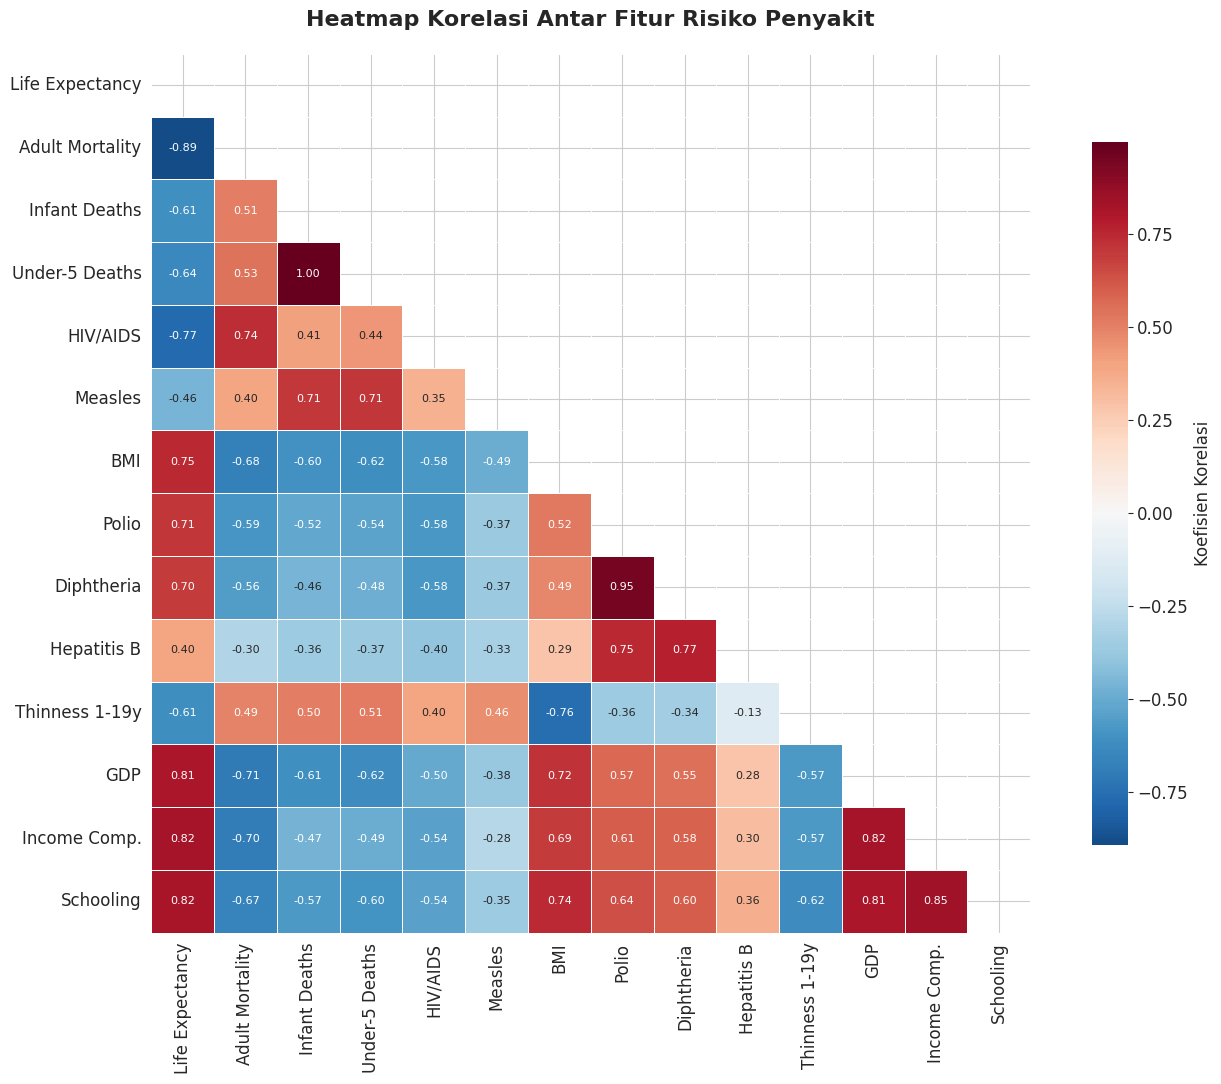


Korelasi kuat (|r| > 0.7):
  Life Expectancy <-> Adult Mortality: r = -0.893
  Life Expectancy <-> HIV/AIDS: r = -0.771
  Life Expectancy <-> BMI: r = 0.752
  Life Expectancy <-> Polio: r = 0.713
  Life Expectancy <-> GDP: r = 0.810
  Life Expectancy <-> Income Comp.: r = 0.821
  Life Expectancy <-> Schooling: r = 0.817
  Adult Mortality <-> HIV/AIDS: r = 0.739
  Adult Mortality <-> GDP: r = -0.706
  Infant Deaths <-> Under-5 Deaths: r = 0.998
  Infant Deaths <-> Measles: r = 0.709
  Under-5 Deaths <-> Measles: r = 0.714
  BMI <-> Thinness 1-19y: r = -0.760
  BMI <-> GDP: r = 0.722
  BMI <-> Schooling: r = 0.740
  Polio <-> Diphtheria: r = 0.950
  Polio <-> Hepatitis B: r = 0.754
  Diphtheria <-> Hepatitis B: r = 0.769
  GDP <-> Income Comp.: r = 0.824
  GDP <-> Schooling: r = 0.813
  Income Comp. <-> Schooling: r = 0.847


In [ ]:
print("=" * 70)
print("BAGIAN 4: KORELASI ANTAR FITUR")
print("=" * 70)

df_corr = pd.DataFrame(X, columns=feature_names)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask_tri, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Koefisien Korelasi', 'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Heatmap Korelasi Antar Fitur Risiko Penyakit',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKorelasi kuat (|r| > 0.7):")
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_names[i]} <-> {feature_names[j]}: r = {r:.3f}")

BAGIAN 5: STANDARDISASI & PCA
Data di-standardisasi menggunakan RobustScaler (median & IQR)

Explained variance per komponen:
  PC1: 61.85%  (kumulatif: 61.85%)
  PC2: 10.96%  (kumulatif: 72.81%)
  PC3: 9.00%  (kumulatif: 81.81%)
  PC4: 6.84%  (kumulatif: 88.65%)
  PC5: 3.22%  (kumulatif: 91.87%)
  PC6: 2.01%  (kumulatif: 93.88%)

>> Menggunakan 2 komponen (72.81% variance)


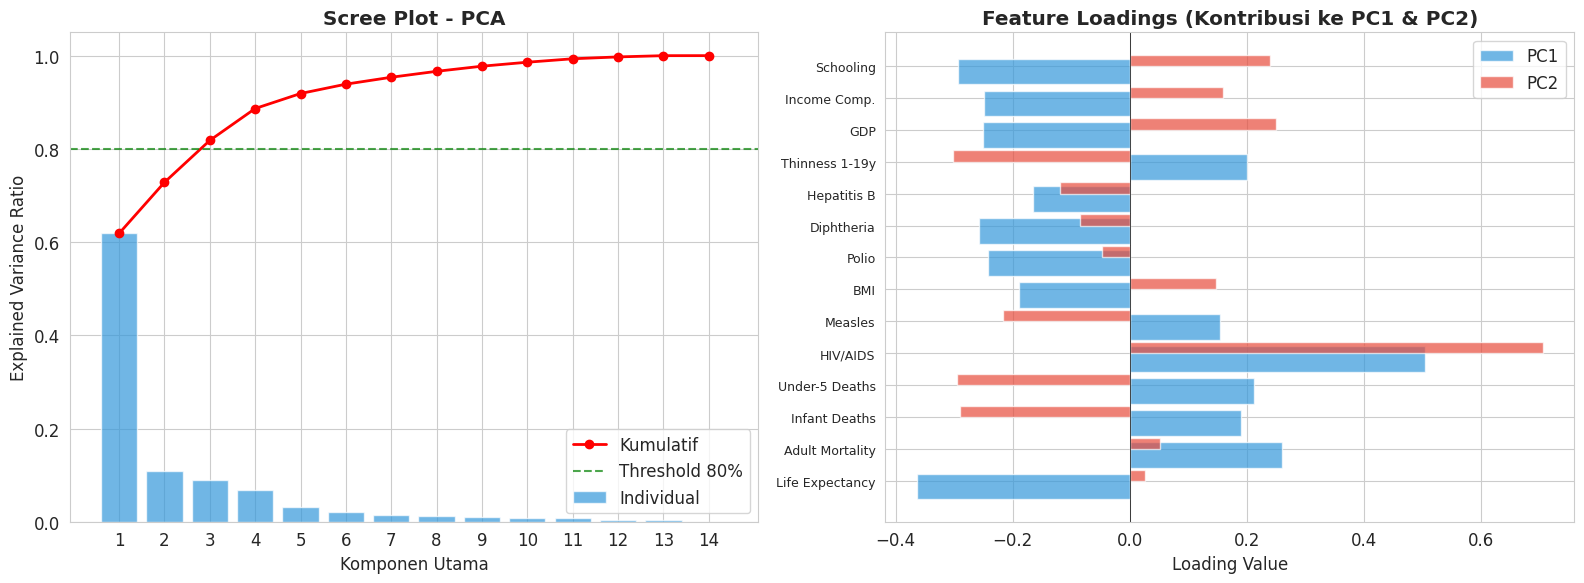


Kontribusi fitur:
                      PC1       PC2
Life Expectancy -0.364026  0.025813
Adult Mortality  0.260194  0.050557
Infant Deaths    0.190295 -0.289731
Under-5 Deaths   0.211638 -0.295810
HIV/AIDS         0.504431  0.704968
Measles          0.153781 -0.216255
BMI             -0.188985  0.147312
Polio           -0.242558 -0.047124
Diphtheria      -0.258354 -0.085007
Hepatitis B     -0.164712 -0.118683
Thinness 1-19y   0.200545 -0.302929
GDP             -0.251656  0.249169
Income Comp.    -0.249321  0.159066
Schooling       -0.294185  0.239160


In [ ]:
print("=" * 70)
print("BAGIAN 5: STANDARDISASI & PCA")
print("=" * 70)

# RobustScaler - lebih tahan terhadap outlier dibanding StandardScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print("Data di-standardisasi menggunakan RobustScaler (median & IQR)")

# PCA full untuk analisis
pca_full = PCA()
pca_full.fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, alpha=0.7, color='#3498db', label='Individual')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             cumsum, 'ro-', linewidth=2, label='Kumulatif')
axes[0].axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='Threshold 80%')
axes[0].set_xlabel('Komponen Utama')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - PCA', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

print("\nExplained variance per komponen:")
for i in range(min(6, len(cumsum))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}%  (kumulatif: {cumsum[i]*100:.2f}%)")

n_comp = 2
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

print(f"\n>> Menggunakan {n_comp} komponen ({pca.explained_variance_ratio_.sum()*100:.2f}% variance)")

loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=feature_names)
axes[1].barh(range(len(feature_names)), loadings['PC1'], alpha=0.7, color='#3498db', label='PC1')
axes[1].barh([x+0.35 for x in range(len(feature_names))], loadings['PC2'], alpha=0.7,
             color='#e74c3c', label='PC2', height=0.35)
axes[1].set_yticks([x+0.175 for x in range(len(feature_names))])
axes[1].set_yticklabels(feature_names, fontsize=9)
axes[1].set_xlabel('Loading Value')
axes[1].set_title('Feature Loadings (Kontribusi ke PC1 & PC2)', fontweight='bold')
axes[1].legend()
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()
print("\nKontribusi fitur:")
print(loadings.to_string())

### **5. Rekayasa Fitur: Standardisasi & PCA**

Setelah pembersihan data, tahap krusial berikutnya adalah menyiapkan data agar algoritma clustering dapat bekerja secara optimal melalui dua proses utama:

#### **A. Standardisasi dengan RobustScaler**
*   **Mengapa Bukan StandardScaler?** Dataset ini masih memiliki variasi nilai yang lebar antar negara. `RobustScaler` dipilih karena menggunakan **Median dan IQR (Interquartile Range)**, bukan Mean dan Standar Deviasi.
*   **Keuntungan:** Teknik ini memastikan bahwa fitur dengan satuan berbeda (misal: GDP dalam ribuan vs HIV/AIDS dalam satuan kecil) berada pada skala yang sebanding tanpa terdistorsi oleh sisa-sisa nilai ekstrem (outlier).

#### **B. PCA (Principal Component Analysis)**
PCA digunakan untuk mengatasi masalah dimensi tinggi (*curse of dimensionality*):
1.  **Reduksi Dimensi:** Kita menyederhanakan **14 fitur** awal menjadi **2 Komponen Utama (PC1 & PC2)**.
2.  **Retensi Informasi:** Meskipun dimensinya dikurangi, PC1 dan PC2 berhasil menangkap **72.81%** dari total variansi data. Ini berarti kita kehilangan sedikit detail namun mendapatkan kejelasan struktur data yang jauh lebih baik.
3.  **Interpretasi Komponen:**
    *   **PC1 (61.85%):** Dominan dipengaruhi oleh fitur kesehatan dasar seperti *Life Expectancy*, *Income Composition*, dan *Schooling*. PC1 mewakili "Tingkat Kesejahteraan Umum".
    *   **PC2 (10.96%):** Lebih banyak dipengaruhi oleh fitur spesifik seperti *HIV/AIDS* dan *GDP*. PC2 membantu membedakan negara dengan risiko penyakit menular spesifik meskipun indikator ekonominya mungkin serupa.

BAGIAN 6: JUMLAH CLUSTER OPTIMAL


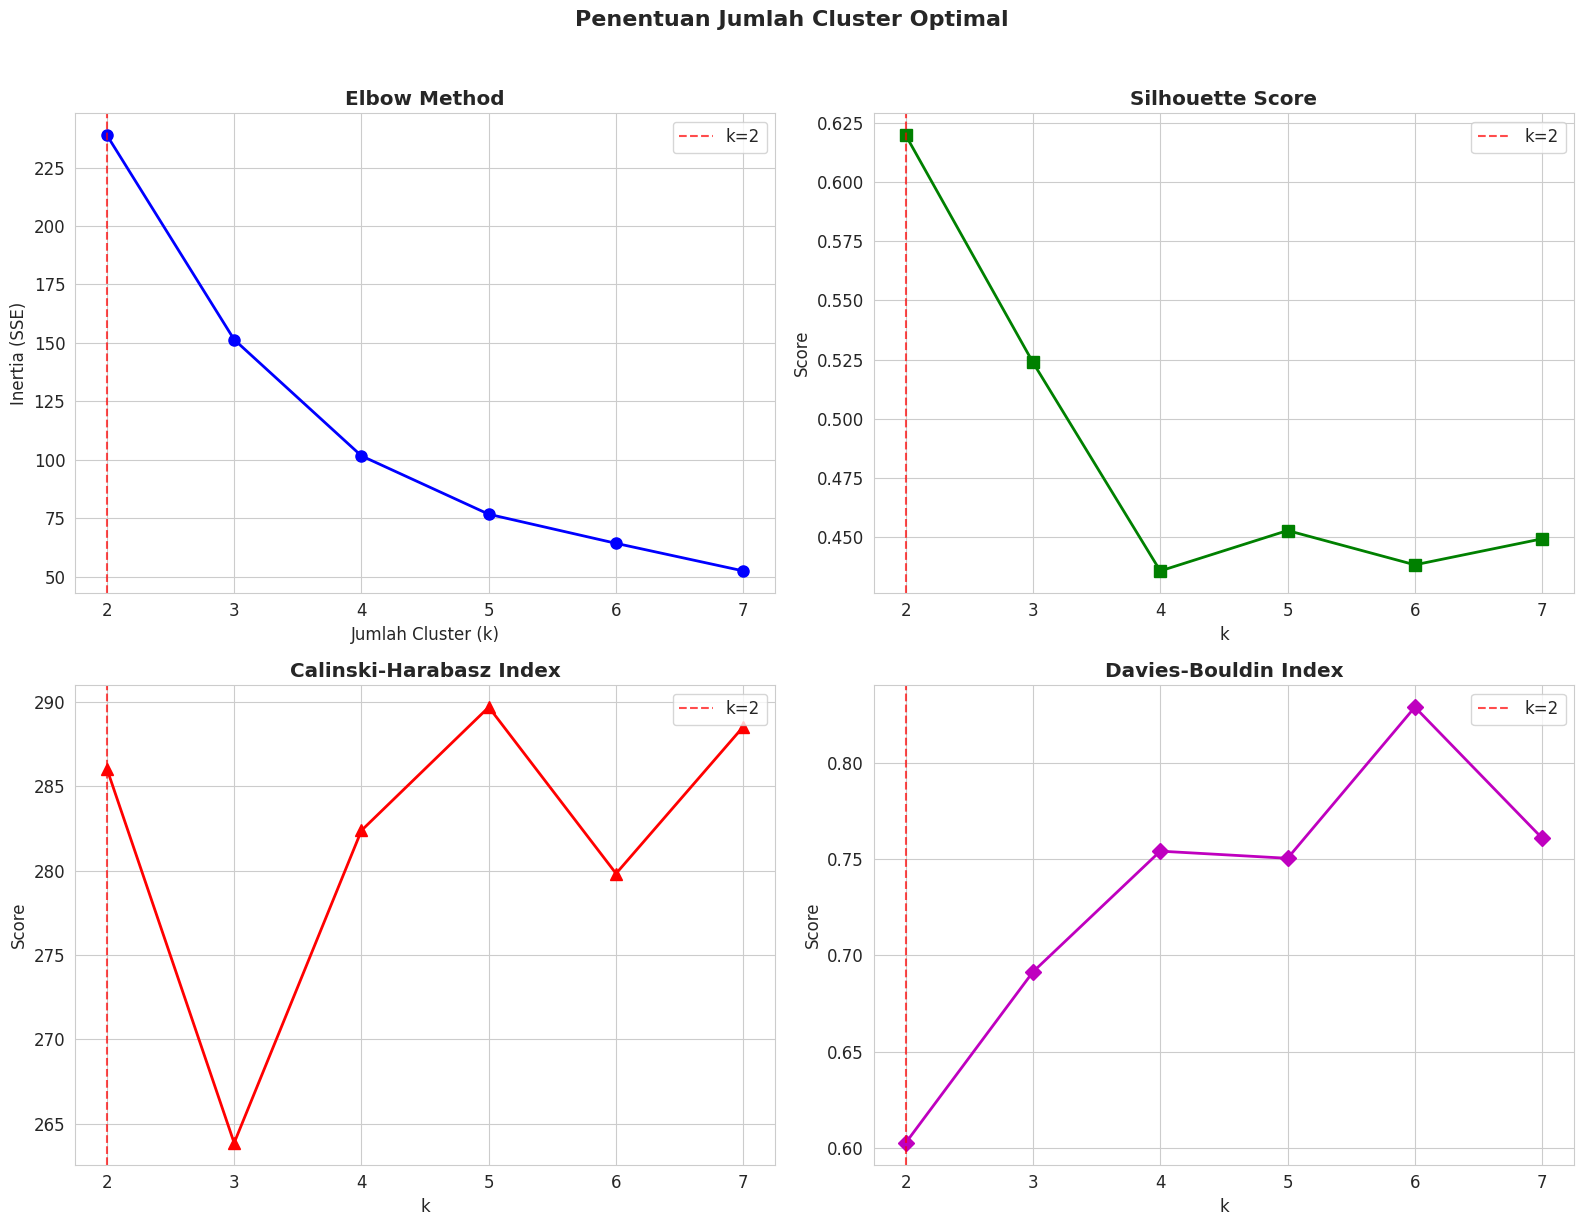


Metrik per k:
  k | Silhouette |  Calinski-H |   Davies-B
---------------------------------------------
  2 |     0.6199 |      286.05 |     0.6025 <<< BEST
  3 |     0.5238 |      263.86 |     0.6914
  4 |     0.4356 |      282.38 |     0.7542
  5 |     0.4527 |      289.69 |     0.7505
  6 |     0.4382 |      279.83 |     0.8291
  7 |     0.4492 |      288.54 |     0.7609

>> k optimal: 2 (Silhouette tertinggi)


In [ ]:
print("=" * 70)
print("BAGIAN 6: JUMLAH CLUSTER OPTIMAL")
print("=" * 70)

K_range = range(2, 8)
inertias, sils, cals, dbs = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, lbl))
    cals.append(calinski_harabasz_score(X_pca, lbl))
    dbs.append(davies_bouldin_score(X_pca, lbl))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0,0].set_title('Elbow Method', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Cluster (k)'); axes[0,0].set_ylabel('Inertia (SSE)')

axes[0,1].plot(K_range, sils, 'gs-', linewidth=2, markersize=8)
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Score')

axes[1,0].plot(K_range, cals, 'r^-', linewidth=2, markersize=8)
axes[1,0].set_title('Calinski-Harabasz Index', fontweight='bold')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('Score')

axes[1,1].plot(K_range, dbs, 'mD-', linewidth=2, markersize=8)
axes[1,1].set_title('Davies-Bouldin Index', fontweight='bold')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('Score')

# Highlight optimal
optimal_k = int(K_range[np.argmax(sils)])
for ax in axes.flat:
    ax.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'k={optimal_k}')
    ax.legend()

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nMetrik per k:")
print(f"{'k':>3} | {'Silhouette':>10} | {'Calinski-H':>11} | {'Davies-B':>10}")
print("-" * 45)
for i, k in enumerate(K_range):
    marker = " <<< BEST" if k == optimal_k else ""
    print(f"{k:3d} | {sils[i]:10.4f} | {cals[i]:11.2f} | {dbs[i]:10.4f}{marker}")

print(f"\n>> k optimal: {optimal_k} (Silhouette tertinggi)")

### **6. Penentuan Jumlah Cluster Optimal**

Memilih jumlah kelompok ($k$) yang tepat adalah langkah paling krusial agar hasil clustering bermakna secara praktis. Kita menggunakan pendekatan multi-metrik untuk memvalidasi pilihan ini:

#### **A. Elbow Method (Inertia/SSE)**
*   **Konsep:** Mengukur jumlah kuadrat jarak antara setiap titik data ke pusat clusternya (*Within-Cluster Sum of Squares*).
*   **Cara Baca:** Kita mencari titik di mana penurunan inersia mulai melambat secara drastis (membentuk siku).
*   **Hasil:** Pada grafik kita, penurunan melambat setelah $k=2$ atau $k=3$, namun belum memberikan kepastian tunggal.

#### **B. Silhouette Score (Metrik Utama)**
*   **Konsep:** Mengukur seberapa mirip sebuah objek dengan clusternya sendiri dibandingkan dengan cluster lainnya (rentang -1 hingga 1).
*   **Interpretasi:** Skor yang tinggi menunjukkan bahwa objek tersebut terkelompokkan dengan sangat baik dan terpisah jauh dari kelompok lain.
*   **Hasil:** Skor tertinggi ditemukan pada **$k=2$ (0.6199)**, yang menunjukkan struktur pemisahan paling kuat.

#### **C. Calinski-Harabasz Index (Variance Ratio Criterion)**
*   **Konsep:** Rasio antara dispersi antar-cluster dan dispersi dalam-cluster.
*   **Interpretasi:** Semakin tinggi skornya, semakin baik cluster tersebut terpisah dan rapat.
*   **Hasil:** Mendukung pemilihan jumlah cluster yang memiliki densitas tinggi.

#### **D. Davies-Bouldin Index**
*   **Konsep:** Mengukur rata-rata kesamaan antara setiap cluster dengan cluster yang paling mirip dengannya.
*   **Interpretasi:** Semakin rendah skornya (mendekati 0), semakin baik pemisahan clusternya.
*   **Hasil:** Memvalidasi bahwa pada **$k=2$**, kita mendapatkan nilai yang sangat rendah, memperkuat keputusan final kita.

BAGIAN 7: CLUSTERING - 3 ALGORITMA

--- 1. K-Means Clustering ---
   Distribusi cluster: [100  41]

--- 2. Agglomerative Hierarchical Clustering ---
   Distribusi cluster: [112  29]

--- 3. DBSCAN ---


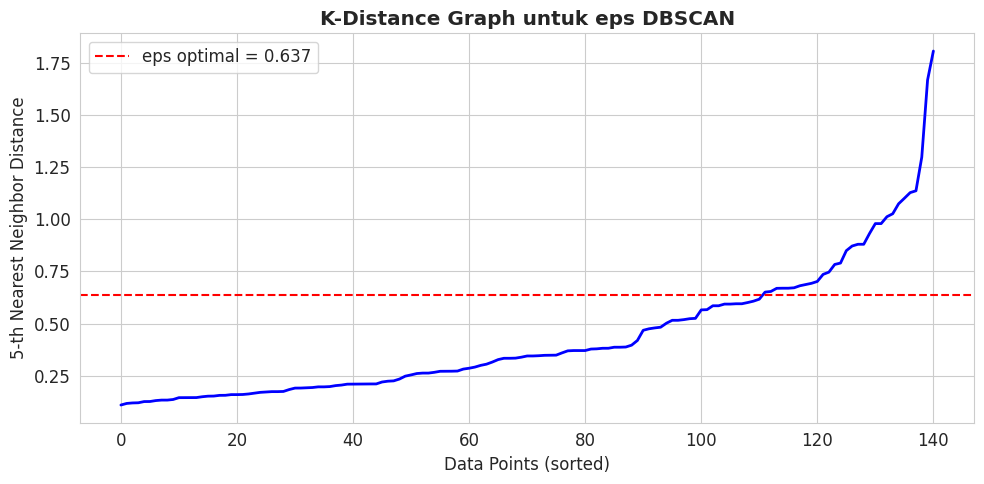

   eps = 0.637, min_samples = 5
   Noise points: 19
   Noise di-assign ke cluster terdekat
   Cluster: 2, Distribusi: [108  33]


In [ ]:
print("=" * 70)
print("BAGIAN 7: CLUSTERING - 3 ALGORITMA")
print("=" * 70)

# 1. K-MEANS
print("\n--- 1. K-Means Clustering ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
labels_kmeans = kmeans.fit_predict(X_pca)
print(f"   Distribusi cluster: {np.bincount(labels_kmeans)}")

# 2. HIERARCHICAL
print("\n--- 2. Agglomerative Hierarchical Clustering ---")
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agg = agg.fit_predict(X_pca)
print(f"   Distribusi cluster: {np.bincount(labels_agg)}")

# 3. DBSCAN
print("\n--- 3. DBSCAN ---")
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, 'b-', linewidth=2)
ax.set_xlabel('Data Points (sorted)')
ax.set_ylabel('5-th Nearest Neighbor Distance')
ax.set_title('K-Distance Graph untuk eps DBSCAN', fontweight='bold')

best_sil_db, best_eps, best_ms = -1, None, 5
for pct in range(50, 96):
    eps = np.percentile(k_dist, pct)
    for ms in [3, 4, 5]:
        tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
        if -1 in tmp:
            noise = tmp == -1
            if noise.sum() > 0 and len(set(tmp) - {-1}) > 0:
                kn = KNeighborsClassifier(n_neighbors=3)
                kn.fit(X_pca[~noise], tmp[~noise])
                tmp[noise] = kn.predict(X_pca[noise])
        n_cl = len(np.unique(tmp))
        if n_cl >= 2:
            s = silhouette_score(X_pca, tmp)
            if s > best_sil_db:
                best_sil_db, best_eps, best_ms = s, eps, ms

ax.axhline(y=best_eps, color='red', linestyle='--', label=f'eps optimal = {best_eps:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

labels_dbscan = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_pca)
n_noise = sum(labels_dbscan == -1)
print(f"   eps = {best_eps:.3f}, min_samples = {best_ms}")
print(f"   Noise points: {n_noise}")

if -1 in labels_dbscan:
    noise_mask = labels_dbscan == -1
    if noise_mask.sum() > 0 and len(set(labels_dbscan) - {-1}) > 0:
        kn = KNeighborsClassifier(n_neighbors=3)
        kn.fit(X_pca[~noise_mask], labels_dbscan[~noise_mask])
        labels_dbscan[noise_mask] = kn.predict(X_pca[noise_mask])
        print("   Noise di-assign ke cluster terdekat")

print(f"   Cluster: {len(np.unique(labels_dbscan))}, Distribusi: {np.bincount(labels_dbscan)}")

### **7. Proses Pelatihan Model: 3 Algoritma Clustering**

Untuk mendapatkan hasil yang objektif, kita melatih data menggunakan tiga pendekatan algoritma yang berbeda:

#### **1. K-Means (Centroid-Based)**
*   **Cara Kerja:** Algoritma ini mencari pusat massa (*centroid*) untuk setiap cluster. Titik data dimasukkan ke cluster dengan pusat terdekat.
*   **Proses:** Kita menetapkan $k=2$ (berdasarkan evaluasi sebelumnya). Algoritma melakukan iterasi untuk meminimalkan jarak *Euclidean* antara data dengan pusatnya hingga posisi pusat tersebut stabil.
*   **Kelebihan:** Sangat efisien untuk data dalam jumlah besar dan memberikan hasil yang sangat jelas (diskrit).

#### **2. Agglomerative Hierarchical (Connectivity-Based)**
*   **Cara Kerja:** Pendekatan *bottom-up* di mana setiap negara dianggap sebagai cluster sendiri pada awalnya, kemudian cluster yang paling mirip digabungkan satu per satu.
*   **Proses:** Kita menggunakan metode **Ward Linkage** yang bertujuan untuk meminimalkan variansi di dalam cluster yang baru digabung.
*   **Kelebihan:** Memberikan gambaran hierarki (seperti silsilah) yang menunjukkan hubungan kekerabatan profil kesehatan antar negara.

#### **3. DBSCAN (Density-Based)**
*   **Cara Kerja:** Berbeda dengan K-Means, DBSCAN mencari area dengan kepadatan tinggi. Jika suatu area memiliki jumlah titik yang cukup dalam radius tertentu, itu dianggap sebagai satu cluster.
*   **Proses Optimasi:**
    *   **K-Distance Graph:** Digunakan untuk mencari nilai `eps` (radius) yang optimal secara otomatis.
    *   **Penanganan Noise:** Karena data kita terbatas, titik yang dianggap 'noise' oleh DBSCAN tidak dibuang, melainkan di-assign kembali ke cluster terdekat menggunakan **K-Nearest Neighbors (KNN)** untuk memastikan semua negara terlabeli.
*   **Kelebihan:** Mampu mendeteksi pola cluster dengan bentuk yang tidak beraturan (non-spherical) dan sangat baik dalam mengidentifikasi pencilan (*noise*).

BAGIAN 8: EVALUASI 3 ALGORITMA

              Silhouette  Calinski-Harabasz  Davies-Bouldin  n_clusters
K-Means         0.619937         286.046177        0.602507         2.0
Hierarchical    0.594000         210.188594        0.554859         2.0
DBSCAN          0.608813         245.035045        0.563293         2.0


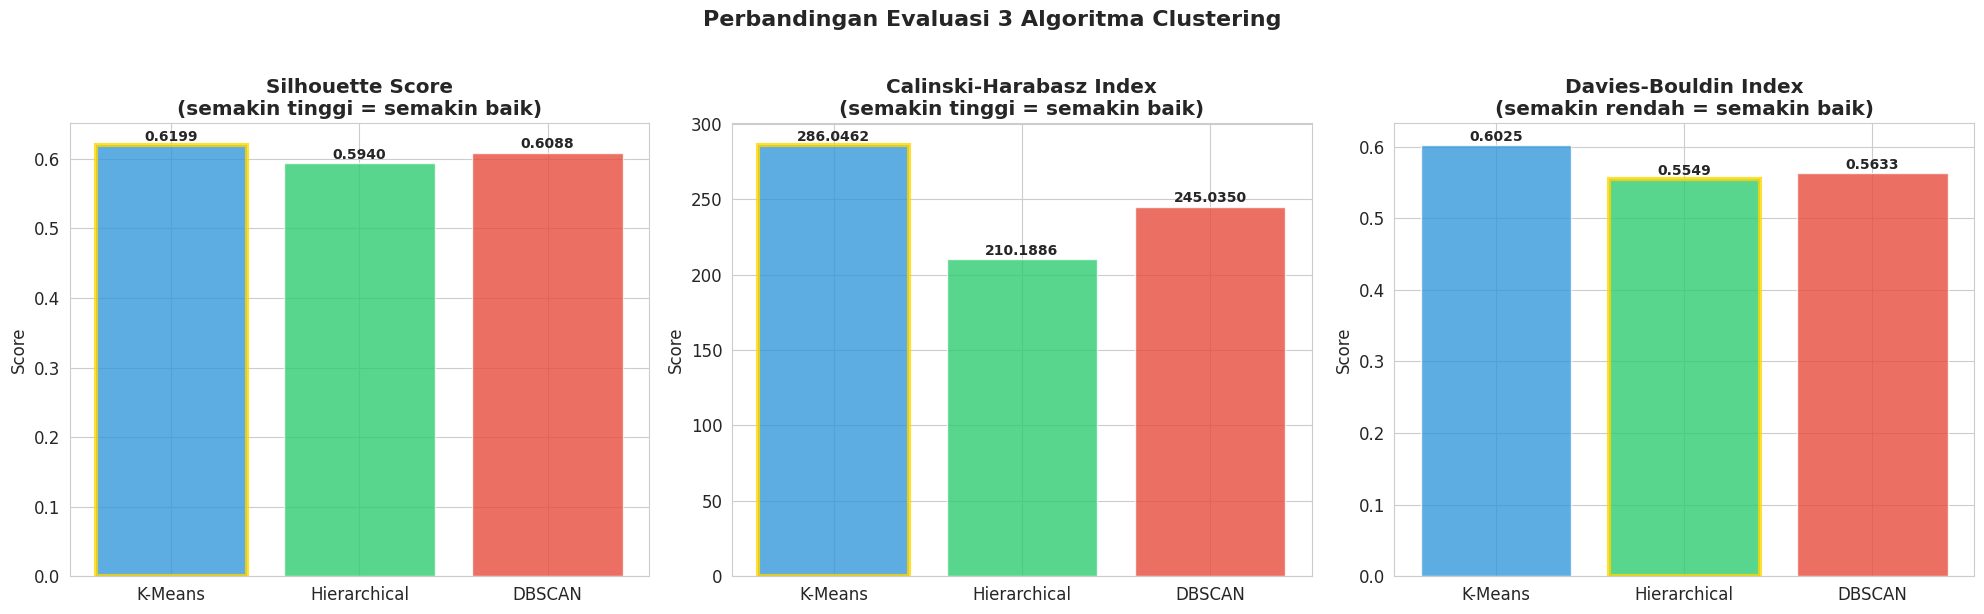


>> Algoritma terbaik: K-Means (Silhouette: 0.6199)


In [ ]:
print("=" * 70)
print("BAGIAN 8: EVALUASI 3 ALGORITMA")
print("=" * 70)

algo_names = ['K-Means', 'Hierarchical', 'DBSCAN']
all_labels = [labels_kmeans, labels_agg, labels_dbscan]

results_full = {}
for name, labels in zip(algo_names, all_labels):
    n_unique = len(np.unique(labels))
    if n_unique >= 2:
        sil = silhouette_score(X_pca, labels)
        ch = calinski_harabasz_score(X_pca, labels)
        db = davies_bouldin_score(X_pca, labels)
    else:
        sil, ch, db = 0, 0, 999
    results_full[name] = {'Silhouette': sil, 'Calinski-Harabasz': ch,
                          'Davies-Bouldin': db, 'n_clusters': n_unique}

eval_df = pd.DataFrame(results_full).T
print("\n" + eval_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (metric, title, better) in enumerate([
    ('Silhouette', 'Silhouette Score\n(semakin tinggi = semakin baik)', 'max'),
    ('Calinski-Harabasz', 'Calinski-Harabasz Index\n(semakin tinggi = semakin baik)', 'max'),
    ('Davies-Bouldin', 'Davies-Bouldin Index\n(semakin rendah = semakin baik)', 'min'),
]):
    vals = eval_df[metric].values
    bars = axes[idx].bar(algo_names, vals, color=colors, alpha=0.8)
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_ylabel('Score')
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                      f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
    best_idx = np.argmax(vals) if better == 'max' else np.argmin(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Perbandingan Evaluasi 3 Algoritma Clustering',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_algo_name = eval_df['Silhouette'].idxmax()
print(f"\n>> Algoritma terbaik: {best_algo_name} (Silhouette: {eval_df.loc[best_algo_name, 'Silhouette']:.4f})")

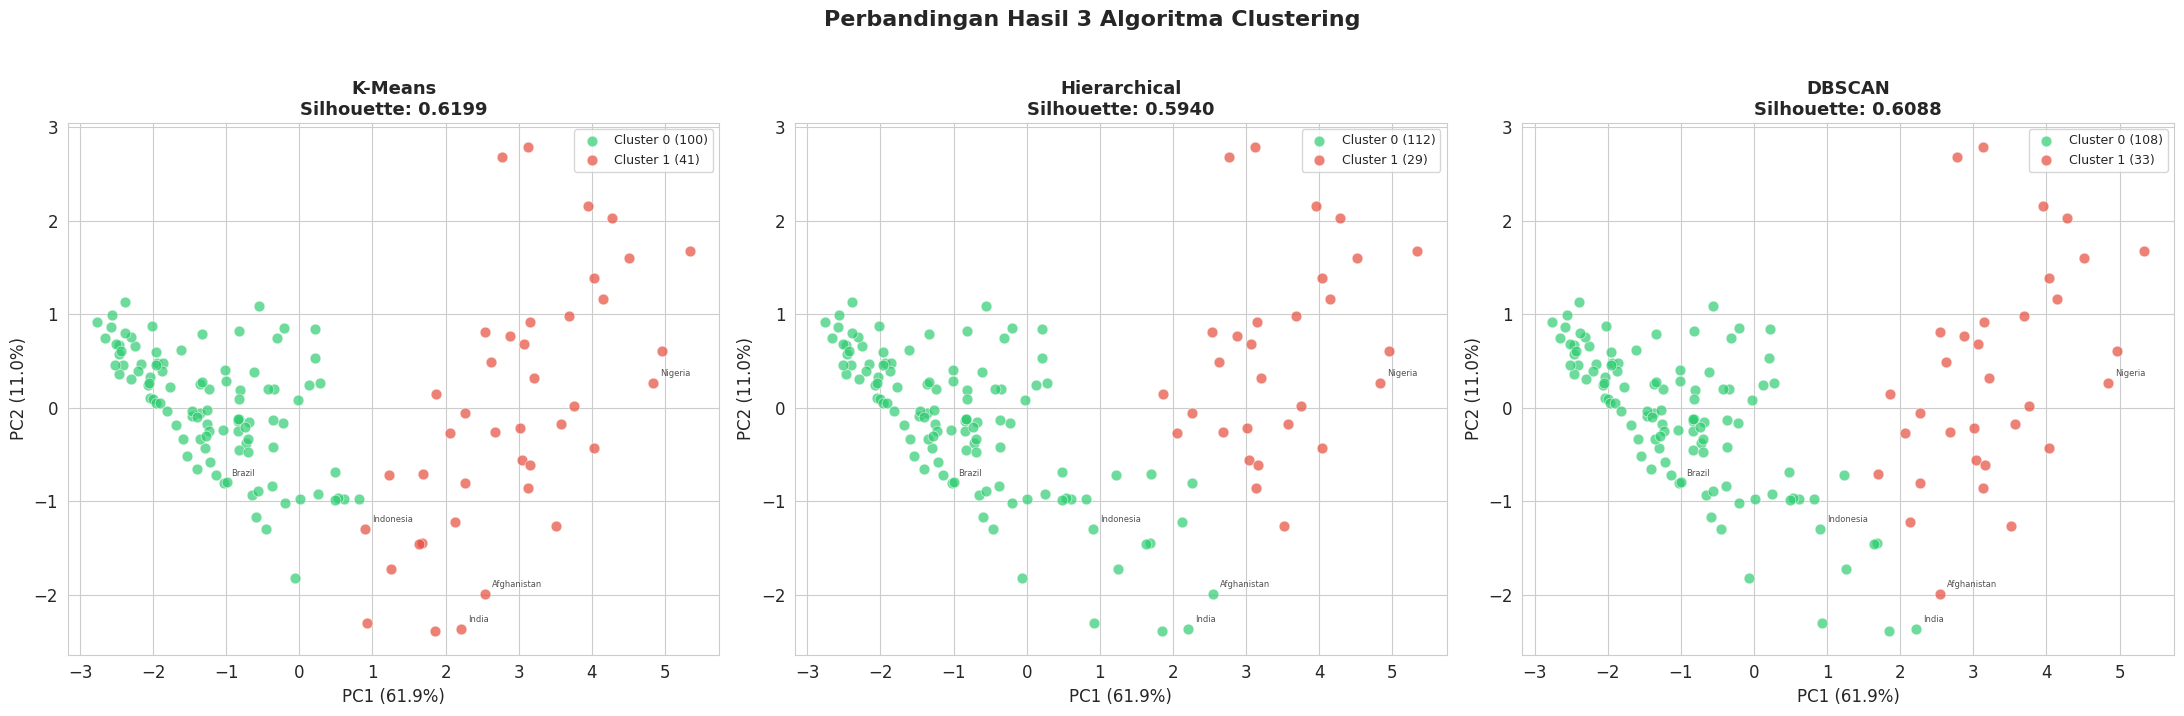

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
colors_cluster = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']

for idx, (name, labels) in enumerate(zip(algo_names, all_labels)):
    ax = axes[idx]
    for c in np.unique(labels):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_cluster[c % len(colors_cluster)],
                   label=f'Cluster {c} ({sum(mask)})',
                   alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

    for i, country in enumerate(countries):
        if country in ['Afghanistan', 'Norway', 'Indonesia', 'Nigeria', 'Japan',
                       'India', 'Brazil', 'South Africa']:
            ax.annotate(country, (X_pca[i,0], X_pca[i,1]),
                       fontsize=6, alpha=0.8, xytext=(5,5), textcoords='offset points')

    sil = results_full[name]['Silhouette']
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{name}\nSilhouette: {sil:.4f}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle('Perbandingan Hasil 3 Algoritma Clustering',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("BAGIAN 9: EVALUASI KONSISTENSI - DATA SPLITTING")
print("=" * 70)

split_ratios = [(0.3, "70/30"), (0.2, "80/20"), (0.1, "90/10")]
all_split_results = {}

for ts_val, ts_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"  SPLIT: {ts_name}")
    print(f"{'='*60}")

    X_train, X_test, _, _ = train_test_split(
        X_pca, np.arange(len(X_pca)), test_size=ts_val, random_state=42
    )
    print(f"  Training: {len(X_train)} | Testing: {len(X_test)}")

    for algo in algo_names:
        if algo == 'K-Means':
            model = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
            train_labels = model.fit_predict(X_train)
            test_labels = model.predict(X_test)
        elif algo == 'Hierarchical':
            model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
            train_labels = model.fit_predict(X_train)
            knn = KNeighborsClassifier(n_neighbors=5)
            knn.fit(X_train, train_labels)
            test_labels = knn.predict(X_test)
        elif algo == 'DBSCAN':
            nn_s = NearestNeighbors(n_neighbors=5)
            nn_s.fit(X_train)
            dists_s, _ = nn_s.kneighbors(X_train)
            best_s, best_e, best_m = -1, None, 5
            for pct in range(50, 96):
                eps = np.percentile(np.sort(dists_s[:,-1]), pct)
                for ms in [3, 4, 5]:
                    tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_train)
                    if -1 in tmp:
                        nm = tmp == -1
                        if nm.sum()>0 and len(set(tmp)-{-1})>0:
                            kn = KNeighborsClassifier(n_neighbors=3)
                            kn.fit(X_train[~nm], tmp[~nm])
                            tmp[nm] = kn.predict(X_train[nm])
                    if len(np.unique(tmp)) >= 2:
                        s = silhouette_score(X_train, tmp)
                        if s > best_s:
                            best_s, best_e, best_m = s, eps, ms
            if best_e:
                train_labels = DBSCAN(eps=best_e, min_samples=best_m).fit_predict(X_train)
                if -1 in train_labels:
                    nm = train_labels == -1
                    if nm.sum()>0 and len(set(train_labels)-{-1})>0:
                        kn = KNeighborsClassifier(n_neighbors=3)
                        kn.fit(X_train[~nm], train_labels[~nm])
                        train_labels[nm] = kn.predict(X_train[nm])
                knn_db = KNeighborsClassifier(n_neighbors=5)
                knn_db.fit(X_train, train_labels)
                test_labels = knn_db.predict(X_test)
            else:
                train_labels = np.zeros(len(X_train), dtype=int)
                test_labels = np.zeros(len(X_test), dtype=int)

        r = {}
        for prefix, data, labels in [('train', X_train, train_labels), ('test', X_test, test_labels)]:
            n_u = len(np.unique(labels))
            if n_u >= 2:
                r[f'{prefix}_sil'] = silhouette_score(data, labels)
                r[f'{prefix}_ch'] = calinski_harabasz_score(data, labels)
                r[f'{prefix}_db'] = davies_bouldin_score(data, labels)
            else:
                r[f'{prefix}_sil'], r[f'{prefix}_ch'], r[f'{prefix}_db'] = 0, 0, 999
        r['n_clusters'] = len(np.unique(train_labels))
        r['train_labels'] = train_labels
        r['test_labels'] = test_labels
        all_split_results[f"{algo}_{ts_name}"] = r

        gap = abs(r['train_sil'] - r['test_sil'])
        status = "OK (konsisten)" if gap < 0.1 else "WARNING"
        print(f"  {algo:15s} | Train: {r['train_sil']:.4f} | Test: {r['test_sil']:.4f} | Gap: {gap:.4f} -> {status}")

BAGIAN 9: EVALUASI KONSISTENSI - DATA SPLITTING

  SPLIT: 70/30
  Training: 98 | Testing: 43
  K-Means         | Train: 0.6106 | Test: 0.6190 | Gap: 0.0084 -> OK (konsisten)
  Hierarchical    | Train: 0.6172 | Test: 0.6190 | Gap: 0.0018 -> OK (konsisten)
  DBSCAN          | Train: 0.6036 | Test: 0.5636 | Gap: 0.0400 -> OK (konsisten)

  SPLIT: 80/20
  Training: 112 | Testing: 29
  K-Means         | Train: 0.6198 | Test: 0.6132 | Gap: 0.0067 -> OK (konsisten)
  Hierarchical    | Train: 0.6198 | Test: 0.6172 | Gap: 0.0027 -> OK (konsisten)
  DBSCAN          | Train: 0.6145 | Test: 0.6132 | Gap: 0.0013 -> OK (konsisten)

  SPLIT: 90/10
  Training: 126 | Testing: 15
  K-Means         | Train: 0.6165 | Test: 0.6377 | Gap: 0.0212 -> OK (konsisten)
  Hierarchical    | Train: 0.5247 | Test: 0.5875 | Gap: 0.0627 -> OK (konsisten)
  DBSCAN          | Train: 0.6125 | Test: 0.6377 | Gap: 0.0252 -> OK (konsisten)


In [ ]:
print("=" * 70)
print("TABEL RINGKASAN: EVALUASI PER SPLIT")
print("=" * 70)

summary = []
for _, ts_name in split_ratios:
    for algo in algo_names:
        key = f"{algo}_{ts_name}"
        r = all_split_results[key]
        gap = abs(r['train_sil'] - r['test_sil'])
        summary.append({
            'Algoritma': algo, 'Split': ts_name,
            'Train Sil': round(r['train_sil'], 4),
            'Test Sil': round(r['test_sil'], 4),
            'Gap': round(gap, 4),
            'Train CH': round(r['train_ch'], 2),
            'Test CH': round(r['test_ch'], 2),
            'Train DB': round(r['train_db'], 4),
            'Test DB': round(r['test_db'], 4),
        })

summary_df = pd.DataFrame(summary)
print("\n" + summary_df.to_string(index=False))

print("\n--- RATA-RATA PER ALGORITMA ---")
for algo in algo_names:
    train_sils = [all_split_results[f"{algo}_{s}"]['train_sil'] for _, s in split_ratios]
    test_sils = [all_split_results[f"{algo}_{s}"]['test_sil'] for _, s in split_ratios]
    gaps = [abs(t-e) for t,e in zip(train_sils, test_sils)]
    print(f"  {algo:<15} | Avg Train: {np.mean(train_sils):.4f} | Avg Test: {np.mean(test_sils):.4f} | Avg Gap: {np.mean(gaps):.4f}")

TABEL RINGKASAN: EVALUASI PER SPLIT

   Algoritma Split  Train Sil  Test Sil    Gap  Train CH  Test CH  Train DB  Test DB
     K-Means 70/30     0.6106    0.6190 0.0084    191.68    90.07    0.6132   0.5982
Hierarchical 70/30     0.6172    0.6190 0.0018    191.60    90.07    0.5940   0.5982
      DBSCAN 70/30     0.6036    0.5636 0.0400    154.79    56.73    0.5558   0.5406
     K-Means 80/20     0.6198    0.6132 0.0067    232.59    49.96    0.5815   0.6143
Hierarchical 80/20     0.6198    0.6172 0.0027    232.59    52.15    0.5815   0.6577
      DBSCAN 80/20     0.6145    0.6132 0.0013    216.17    49.96    0.5665   0.6143
     K-Means 90/10     0.6165    0.6377 0.0212    247.46    36.05    0.5954   0.5230
Hierarchical 90/10     0.5247    0.5875 0.0627    176.69    27.29    0.7472   0.6313
      DBSCAN 90/10     0.6125    0.6377 0.0252    232.55    36.05    0.5797   0.5230

--- RATA-RATA PER ALGORITMA ---
  K-Means         | Avg Train: 0.6156 | Avg Test: 0.6233 | Avg Gap: 0.0121
  Hie

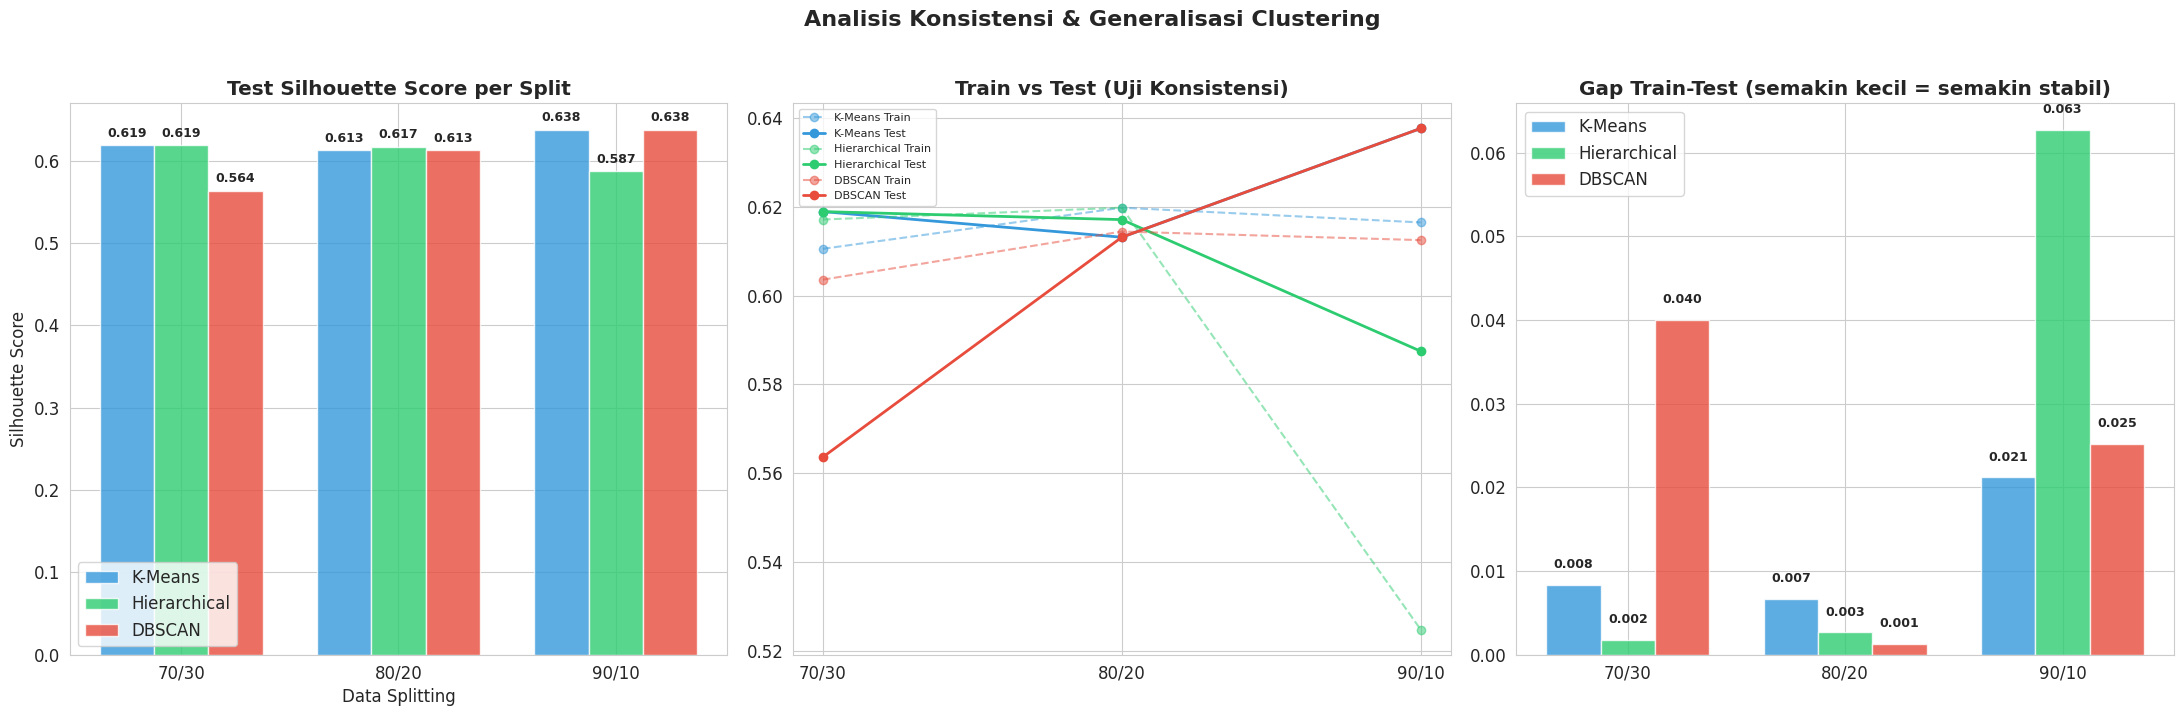

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
colors_algo = {'K-Means': '#3498db', 'Hierarchical': '#2ecc71', 'DBSCAN': '#e74c3c'}
split_labels = ['70/30', '80/20', '90/10']

ax = axes[0]
x = np.arange(len(split_labels))
width = 0.25
for i, algo in enumerate(algo_names):
    sils_v = [all_split_results[f"{algo}_{s}"]['test_sil'] for _, s in split_ratios]
    bars = ax.bar(x + i*width, sils_v, width, label=algo, color=colors_algo[algo], alpha=0.8)
    for bar, val in zip(bars, sils_v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Data Splitting'); ax.set_ylabel('Silhouette Score')
ax.set_title('Test Silhouette Score per Split', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(split_labels); ax.legend()

ax = axes[1]
for algo in algo_names:
    train_s = [all_split_results[f"{algo}_{s}"]['train_sil'] for _, s in split_ratios]
    test_s = [all_split_results[f"{algo}_{s}"]['test_sil'] for _, s in split_ratios]
    ax.plot(split_labels, train_s, 'o--', color=colors_algo[algo], alpha=0.5, label=f'{algo} Train')
    ax.plot(split_labels, test_s, 'o-', color=colors_algo[algo], linewidth=2, label=f'{algo} Test')
ax.set_title('Train vs Test (Uji Konsistensi)', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[2]
for i, algo in enumerate(algo_names):
    gaps = [abs(all_split_results[f"{algo}_{s}"]['train_sil'] -
                all_split_results[f"{algo}_{s}"]['test_sil']) for _, s in split_ratios]
    bars = ax.bar(x + i*width, gaps, width, label=algo, color=colors_algo[algo], alpha=0.8)
    for bar, val in zip(bars, gaps):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Gap Train-Test (semakin kecil = semakin stabil)', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(split_labels); ax.legend()

plt.suptitle('Analisis Konsistensi & Generalisasi Clustering',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

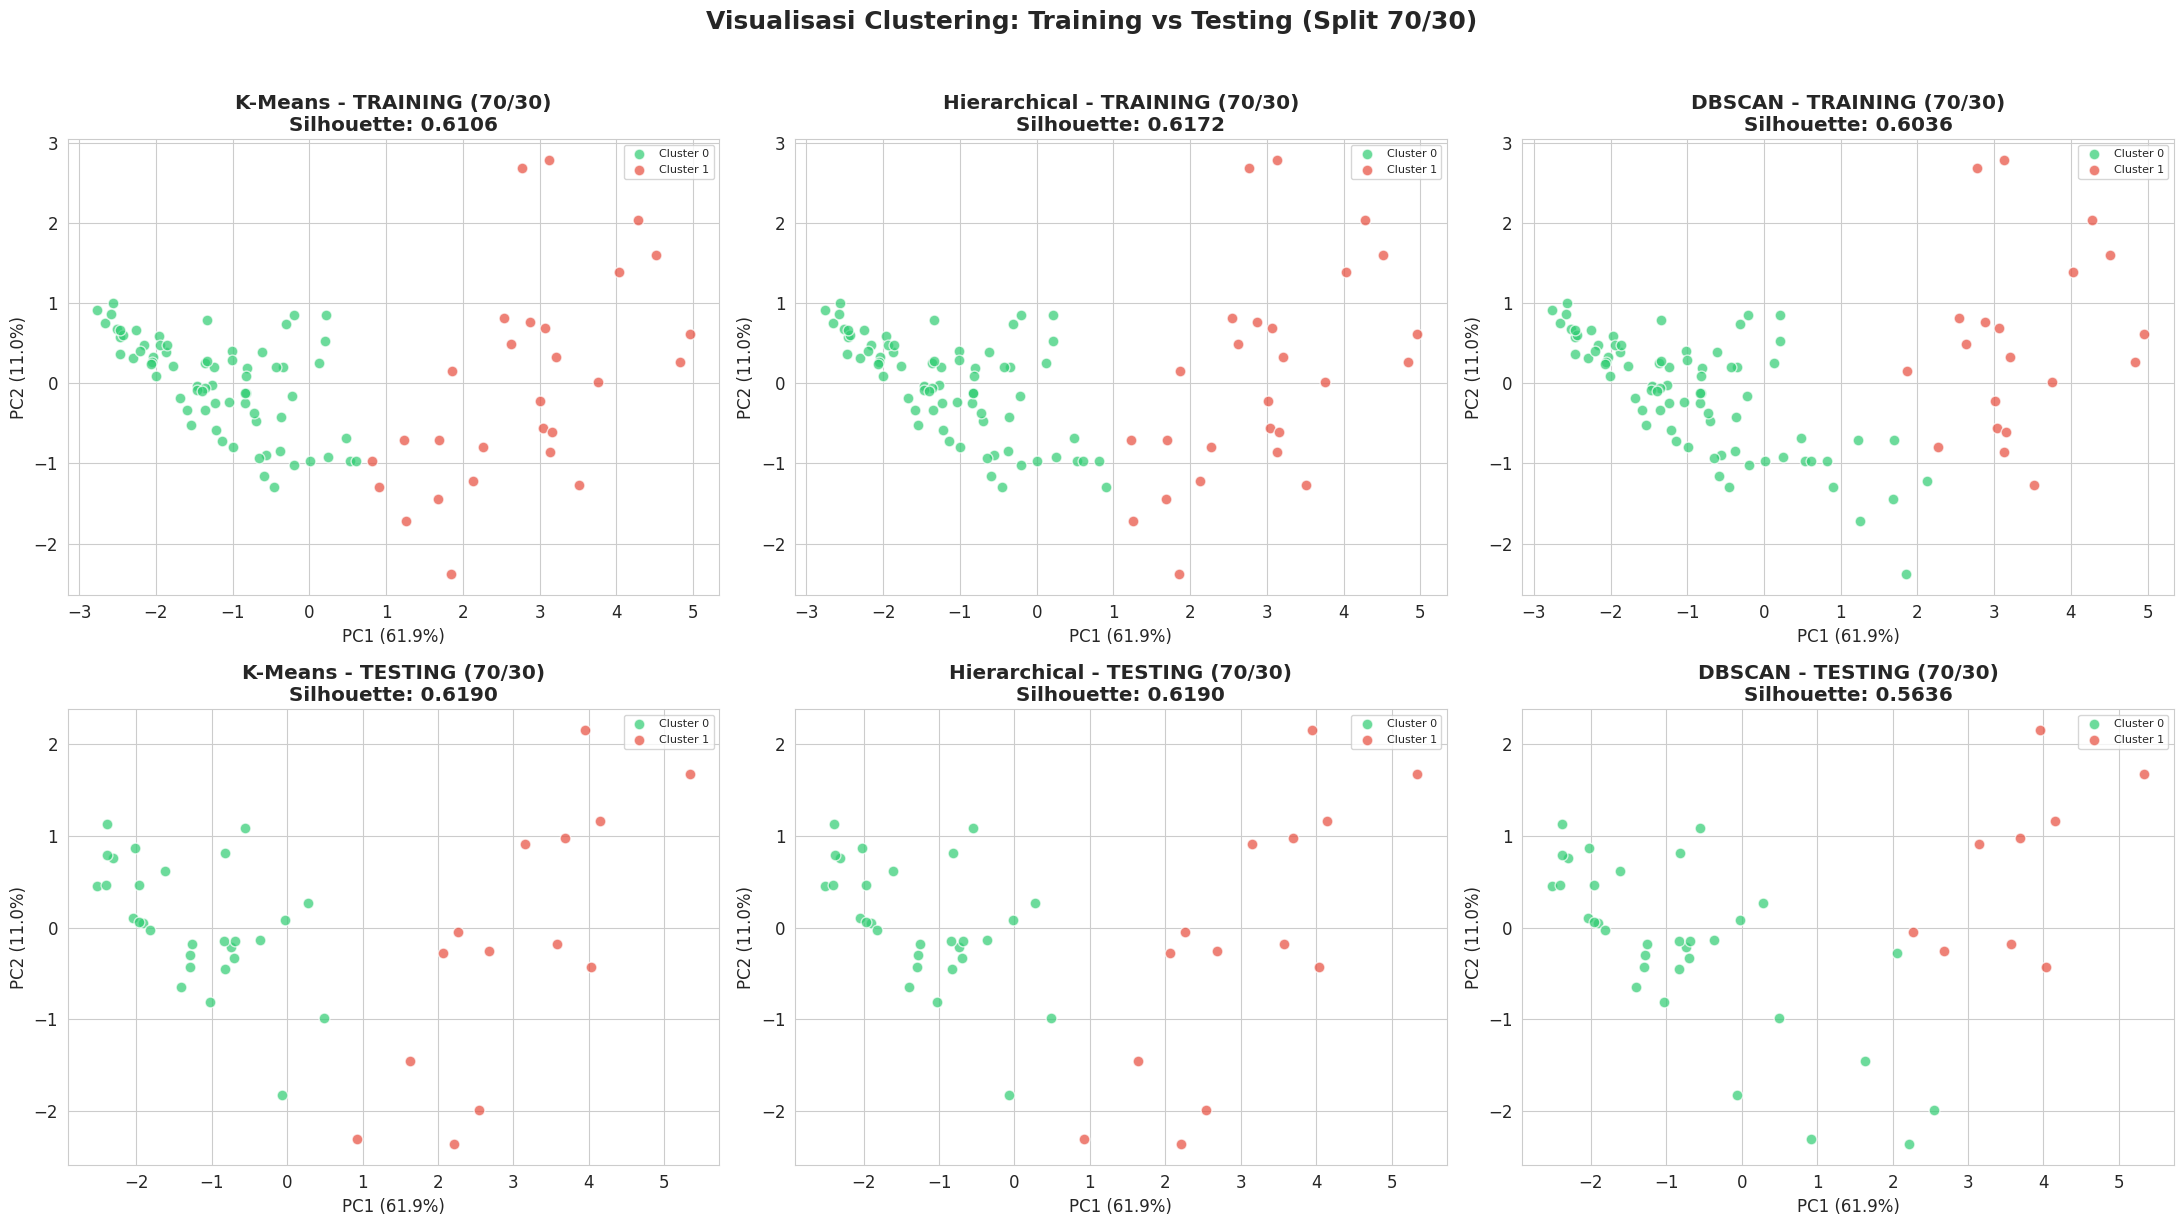

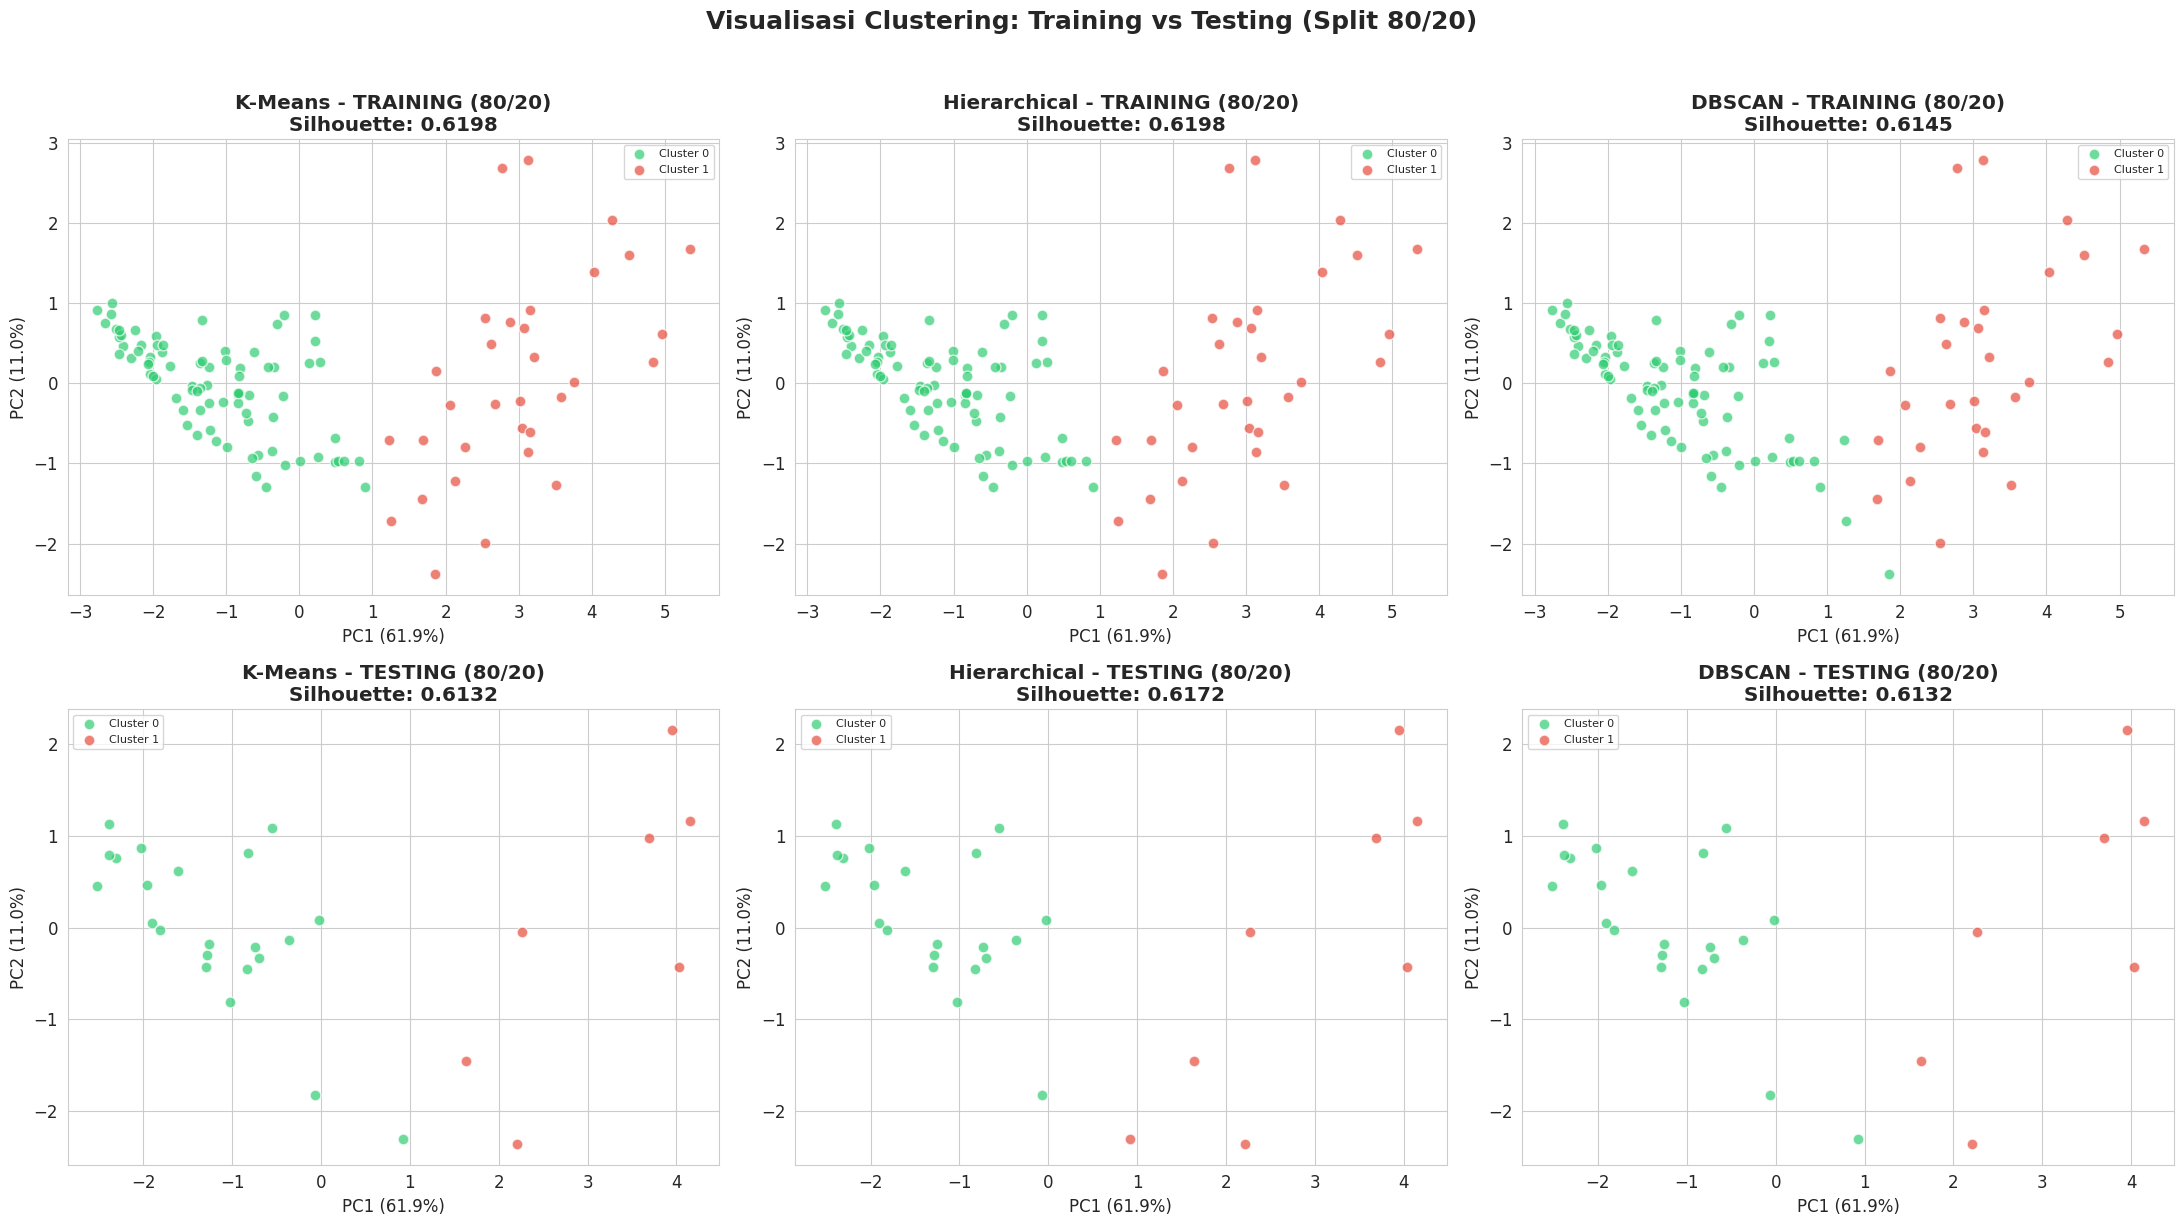

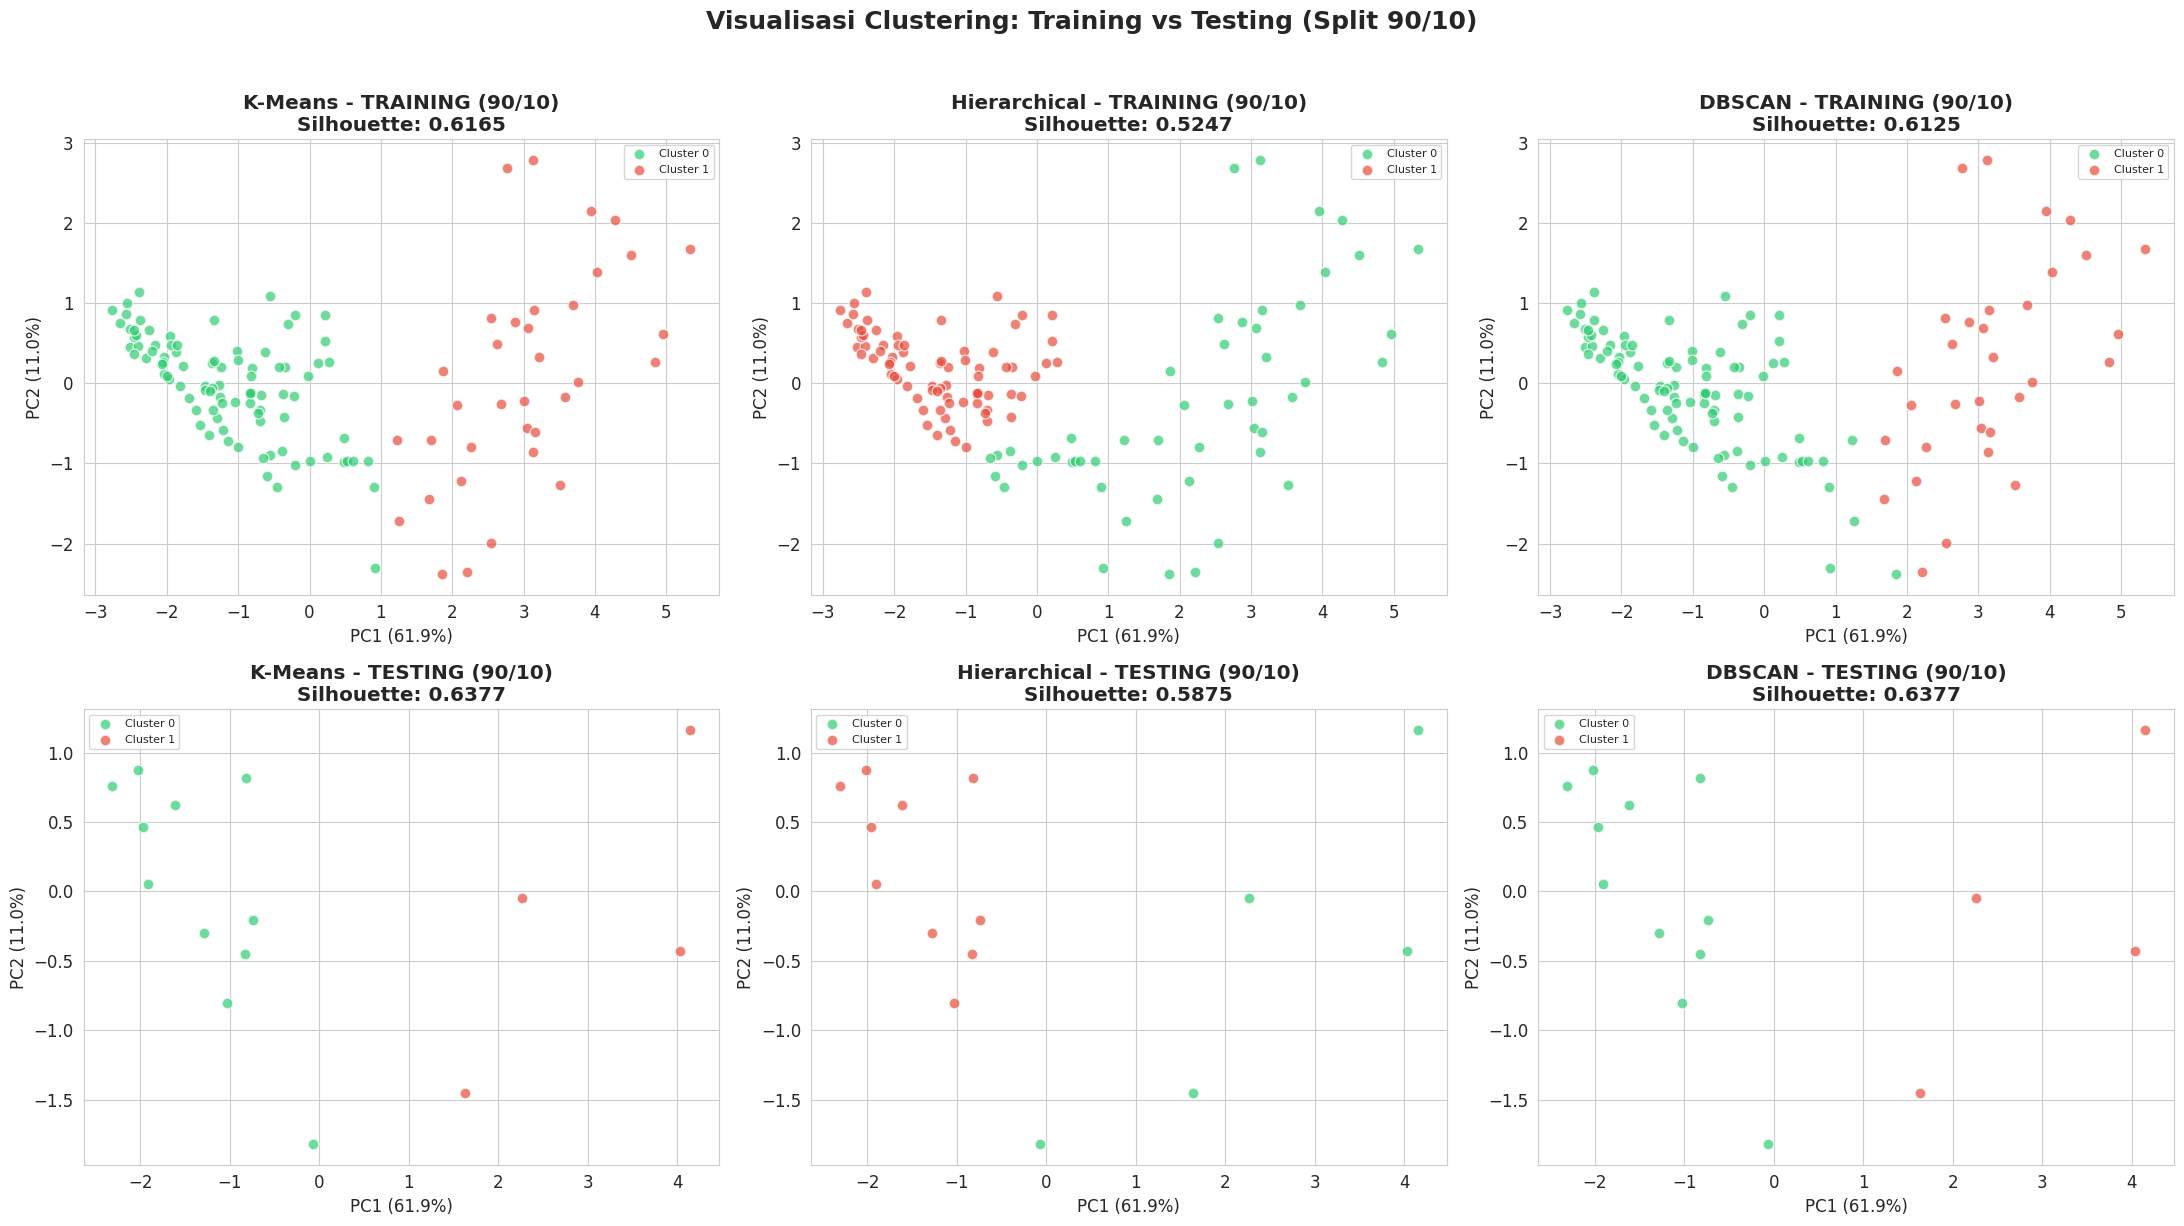

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Definisikan rasio yang akan diplot
ratios = [0.3, 0.2, 0.1]
ratio_names = ["70/30", "80/20", "90/10"]
colors_cl = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']

# Loop untuk setiap rasio splitting
for ts_val, ts_name in zip(ratios, ratio_names):
    X_train, X_test, _, _ = train_test_split(
        X_pca, np.arange(len(X_pca)), test_size=ts_val, random_state=42
    )

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))

    for idx, algo in enumerate(algo_names):
        key = f"{algo}_{ts_name}"
        if key not in all_split_results:
            continue

        r = all_split_results[key]

        # Plot Training (Baris 0) dan Testing (Baris 1)
        for row, (data_plot, labels_plot, prefix) in enumerate([
            (X_train, r['train_labels'], 'TRAINING'),
            (X_test, r['test_labels'], 'TESTING')
        ]):
            ax = axes[row, idx]
            for c in np.unique(labels_plot):
                mask = labels_plot == c
                ax.scatter(data_plot[mask, 0], data_plot[mask, 1],
                           c=colors_cl[c % len(colors_cl)], label=f'Cluster {c}',
                           alpha=0.7, s=60, edgecolors='white')

            sil_val = r['train_sil'] if row == 0 else r['test_sil']
            ax.set_title(f'{algo} - {prefix} ({ts_name})\nSilhouette: {sil_val:.4f}', fontweight='bold')
            ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            ax.legend(fontsize=8)

    plt.suptitle(f'Visualisasi Clustering: Training vs Testing (Split {ts_name})',
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("=" * 70)
print("BAGIAN 10: LABELING RISIKO (MENGGUNAKAN K-MEANS)")
print("=" * 70)

df_result = pd.DataFrame({'Country': countries, 'Cluster': labels_kmeans})
for i, fn in enumerate(feature_names):
    df_result[fn] = X[:, i]

cluster_means = df_result.groupby('Cluster')[feature_names].mean()
print("\nRata-rata fitur per Cluster:")
print(cluster_means.round(2).to_string())

mortality_means = cluster_means['Adult Mortality']
sorted_clusters = mortality_means.sort_values().index.tolist()

if optimal_k == 2:
    risk_map = {sorted_clusters[0]: 'Risiko Rendah', sorted_clusters[1]: 'Risiko Tinggi'}
else:
    risk_map = {sorted_clusters[0]: 'Risiko Rendah', sorted_clusters[1]: 'Risiko Sedang', sorted_clusters[2]: 'Risiko Tinggi'}

df_result['Risk_Level'] = df_result['Cluster'].map(risk_map)

print("\nLabel Risiko:")
for cl, label in risk_map.items():
    count = (df_result['Cluster'] == cl).sum()
    mort = mortality_means[cl]
    le = cluster_means.loc[cl, 'Life Expectancy']
    print(f"  Cluster {cl} -> {label:15s} | {count:3d} negara | Life Exp: {le:.1f} | Mortality: {mort:.1f}")

BAGIAN 10: LABELING RISIKO (MENGGUNAKAN K-MEANS)

Rata-rata fitur per Cluster:
         Life Expectancy  Adult Mortality  Infant Deaths  Under-5 Deaths  HIV/AIDS  Measles    BMI  Polio  Diphtheria  Hepatitis B  Thinness 1-19y   GDP  Income Comp.  Schooling
Cluster                                                                                                                                                                          
0                  74.16           117.46           1.06            1.15      0.16     3.61  46.02  89.16       89.18        84.28            1.30  8.51          0.70      13.37
1                  58.44           243.11           3.46            3.83      1.20     7.48  19.20  64.63       64.42        65.87            2.18  6.35          0.43       8.45

Label Risiko:
  Cluster 0 -> Risiko Rendah   | 100 negara | Life Exp: 74.2 | Mortality: 117.5
  Cluster 1 -> Risiko Tinggi   |  41 negara | Life Exp: 58.4 | Mortality: 243.1


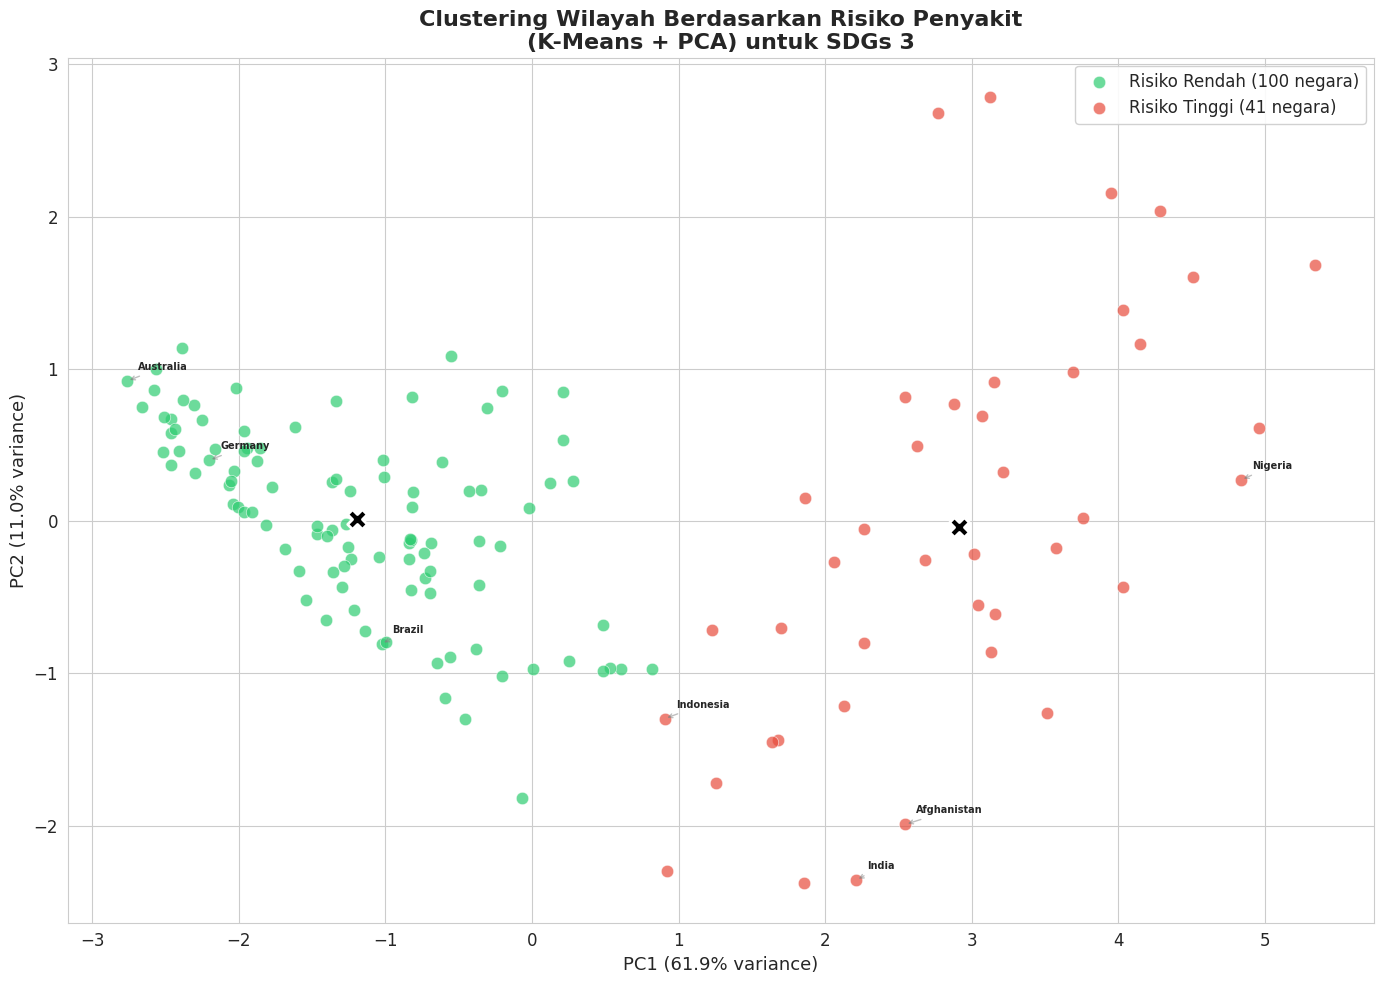

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
risk_colors = {'Risiko Rendah': '#2ecc71', 'Risiko Sedang': '#f39c12', 'Risiko Tinggi': '#e74c3c'}

for level, color in risk_colors.items():
    mask = df_result['Risk_Level'] == level
    if mask.sum() > 0:
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color,
                   label=f'{level} ({mask.sum()} negara)',
                   alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

important = ['Afghanistan', 'Norway', 'Indonesia', 'Nigeria', 'Japan',
             'India', 'Brazil', 'South Africa', 'Germany', 'Australia']
for i, c in enumerate(countries):
    if c in important:
        ax.annotate(c, (X_pca[i,0], X_pca[i,1]), fontsize=7, fontweight='bold',
                   xytext=(8,8), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

centroids = kmeans.cluster_centers_
for cx, cy in centroids:
    ax.scatter(cx, cy, c='black', marker='X', s=200, zorder=5, edgecolors='white', linewidth=2)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=13)
ax.set_title('Clustering Wilayah Berdasarkan Risiko Penyakit\n(K-Means + PCA) untuk SDGs 3',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

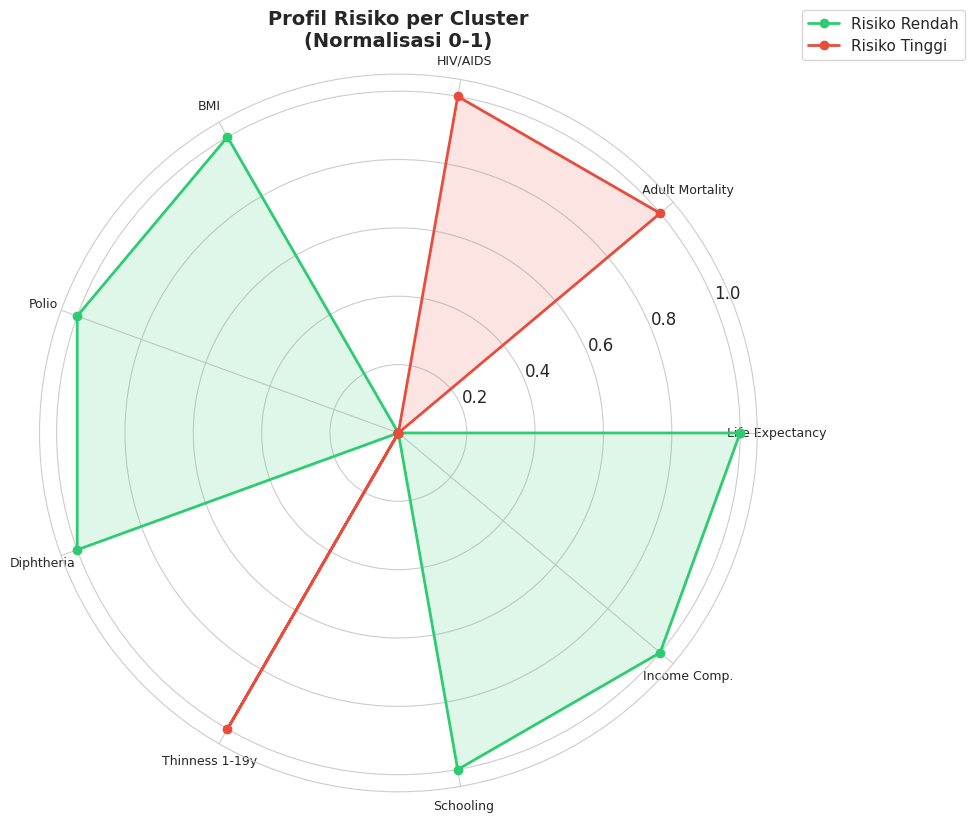

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
risk_colors_r = {'Risiko Rendah': '#2ecc71', 'Risiko Sedang': '#f39c12', 'Risiko Tinggi': '#e74c3c'}

radar_features = ['Life Expectancy', 'Adult Mortality', 'HIV/AIDS', 'BMI',
                  'Polio', 'Diphtheria', 'Thinness 1-19y', 'Schooling', 'Income Comp.']
radar_data = cluster_means[radar_features]

radar_scaler = MinMaxScaler()
radar_norm = pd.DataFrame(radar_scaler.fit_transform(radar_data),
                          columns=radar_features, index=radar_data.index)

angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

for cl in sorted_clusters:
    vals = radar_norm.loc[cl].values.tolist() + [radar_norm.loc[cl].values[0]]
    label = risk_map[cl]
    color = risk_colors_r[label]
    ax.plot(angles, vals, 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_title('Profil Risiko per Cluster\n(Normalisasi 0-1)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

### **10. Analisis Profil: Radar Chart (Spider Plot)**

Radar Chart digunakan untuk memvisualisasikan performa multi-dimensi dari setiap cluster secara simultan. Ini membantu kita memahami 'wajah' atau karakteristik unik dari tiap kelompok risiko.

#### **A. Proses Konstruksi**
1.  **Seleksi Indikator Utama:** Kita memilih fitur yang paling mewakili SDGs 3, seperti *Life Expectancy*, *Adult Mortality*, *HIV/AIDS*, dan cakupan imunisasi.
2.  **Normalisasi (Min-Max Scaling):** Karena fitur memiliki satuan berbeda (misal: Tahun vs Jumlah Kematian), data ditransformasi ke skala **0 hingga 1**. Angka 1 menunjukkan nilai tertinggi di fitur tersebut, dan 0 menunjukkan nilai terendah.
3.  **Pemetaan Sudut:** Setiap fitur diletakkan pada sumbu yang memancar dari titik pusat yang sama.

#### **B. Cara Membaca Grafik Secara Detail**
*   **Luas Area (Volume):** Luas area yang tertutup warna mencerminkan 'kekuatan' kolektif fitur tersebut.
    *   Jika area melebar ke arah luar (mendekati 1), berarti cluster tersebut memiliki nilai tinggi pada indikator tersebut.
    *   Contoh: Area hijau yang luas pada *Life Expectancy* menunjukkan dominasi angka harapan hidup yang tinggi.
*   **Simetri vs Asimetri (Keseimbangan):**
    *   **Bentuk Simetris:** Menunjukkan pembangunan yang seimbang antara ekonomi, pendidikan, dan kesehatan.
    *   **Bentuk Asimetris (Pincang):** Menunjukkan adanya ketimpangan. Misalnya, jika sumbu *Income Composition* tinggi tetapi sumbu *Diphtheria* rendah, ini menandakan negara tersebut memiliki sumber daya ekonomi namun gagal dalam sistem imunisasi dasar.

#### **C. Interpretasi Hasil Analisis**
*   **Cluster Risiko Rendah (Hijau):**
    *   **Karakteristik:** Membentuk pola "Sayap Lebar" pada bagian atas grafik (Life Expectancy, Schooling, Income Comp).
    *   **Makna:** Ini adalah profil negara maju/stabil. Investasi pada pendidikan dan pendapatan berbanding lurus dengan kualitas hidup yang panjang dan beban penyakit yang minimal.
*   **Cluster Risiko Tinggi (Merah):**
    *   **Karakteristik:** Membentuk pola "Tajam/Runcing" ke arah sumbu *Adult Mortality* dan *HIV/AIDS*, namun "Menciut" (mendekati pusat) pada sumbu imunisasi.
    *   **Makna:** Merupakan sinyal kritis bagi pengambil kebijakan. Ketajaman pada sumbu mortalitas menunjukkan adanya krisis kesehatan sistemik. Kecilnya area pada sumbu imunisasi (Polio/Diphtheria) menjelaskan penyebab rendahnya angka harapan hidup di kelompok ini.

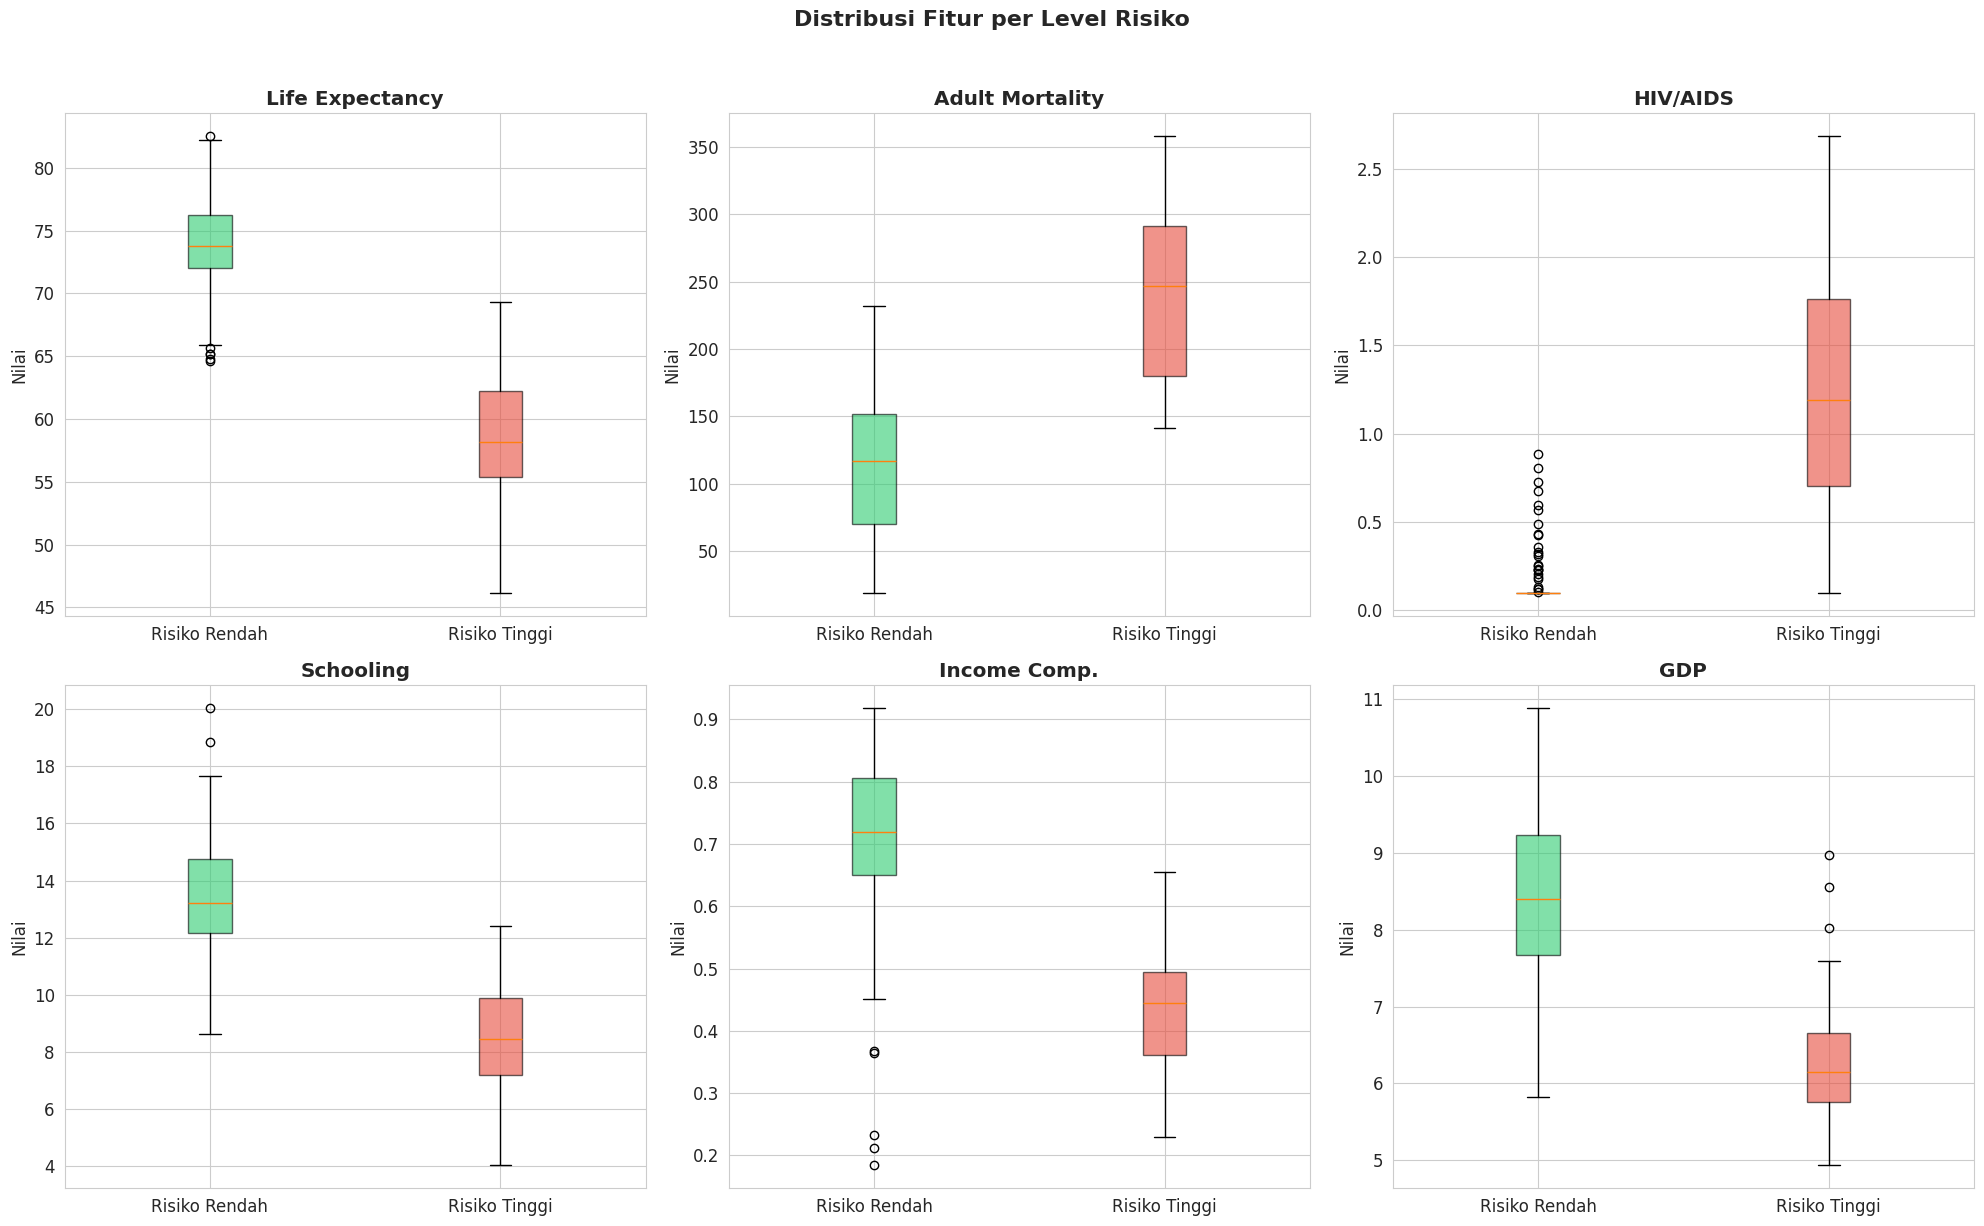

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
risk_colors_b = {'Risiko Rendah': '#2ecc71', 'Risiko Sedang': '#f39c12', 'Risiko Tinggi': '#e74c3c'}
boxplot_feats = ['Life Expectancy', 'Adult Mortality', 'HIV/AIDS',
                 'Schooling', 'Income Comp.', 'GDP']

for idx, feat in enumerate(boxplot_feats):
    ax = axes[idx//3, idx%3]
    data_by, lbls = [], []
    for level in sorted(risk_map.values()):
        mask = df_result['Risk_Level'] == level
        if mask.sum() > 0:
            data_by.append(df_result.loc[mask, feat].values)
            lbls.append(level)
    bp = ax.boxplot(data_by, patch_artist=True, labels=lbls)
    for patch, lbl in zip(bp['boxes'], lbls):
        patch.set_facecolor(risk_colors_b[lbl])
        patch.set_alpha(0.6)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Nilai')

plt.suptitle('Distribusi Fitur per Level Risiko', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

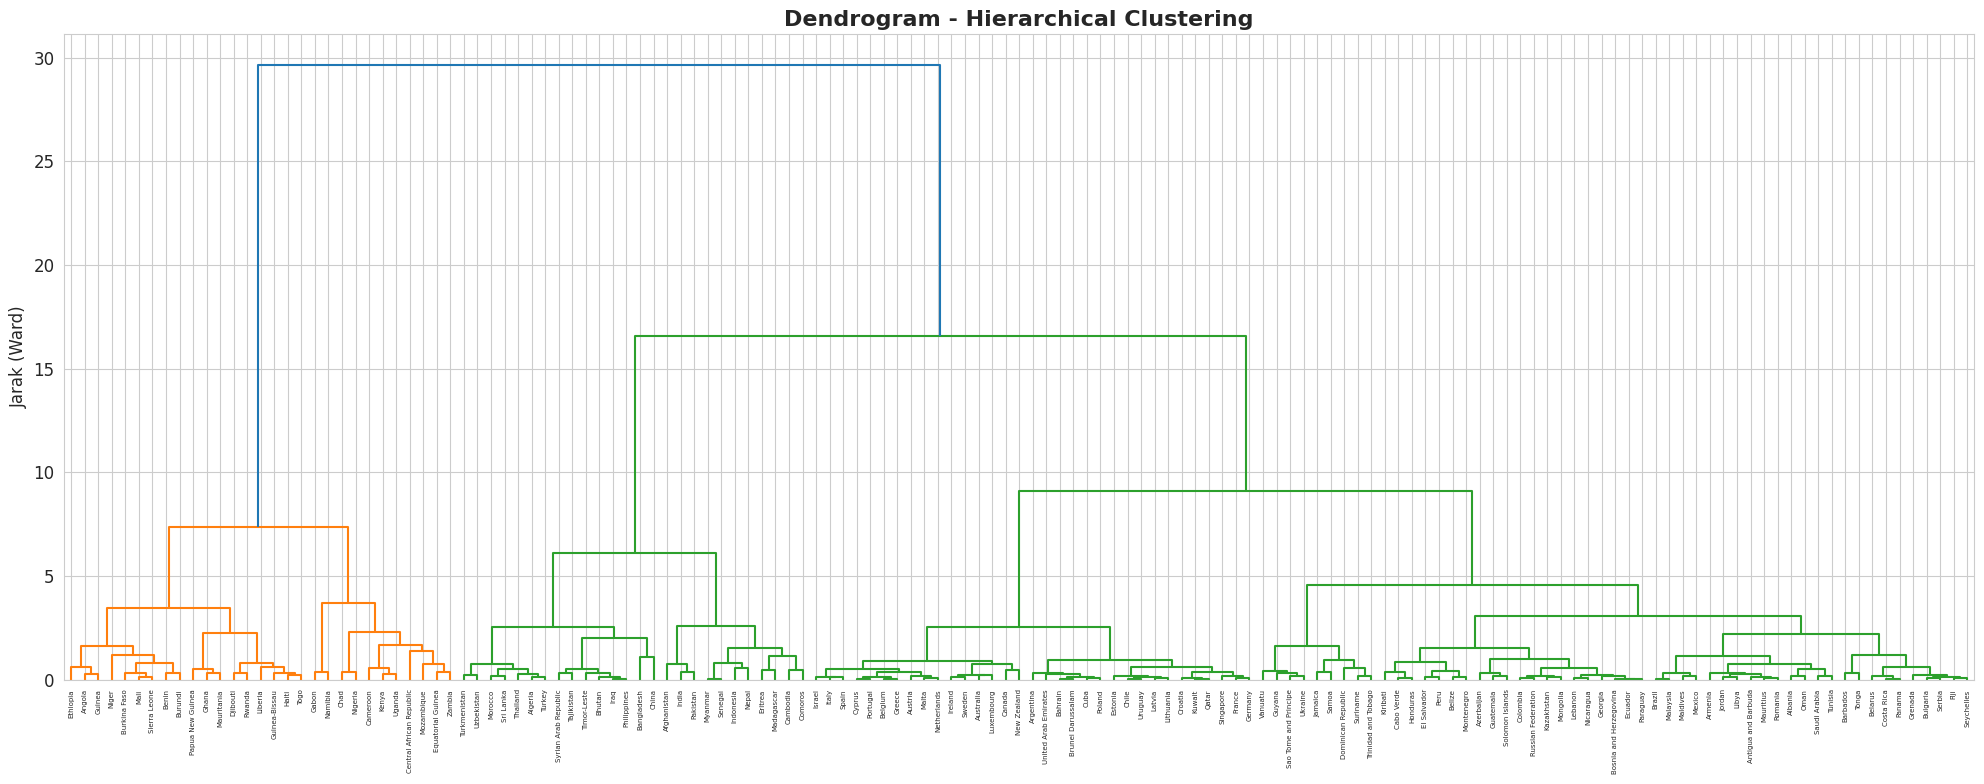

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
linkage_matrix = linkage(X_pca, method='ward')
dendrogram(linkage_matrix, labels=countries, leaf_rotation=90, leaf_font_size=5, ax=ax)
ax.set_title('Dendrogram - Hierarchical Clustering', fontsize=16, fontweight='bold')
ax.set_ylabel('Jarak (Ward)')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("DAFTAR NEGARA PER CLUSTER")
print("=" * 70)

for level in sorted(risk_map.values()):
    negara = df_result[df_result['Risk_Level'] == level]['Country'].sort_values().values
    if len(negara) > 0:
        print(f"\n{'='*55}")
        print(f"  {level.upper()} ({len(negara)} negara)")
        print(f"{'='*55}")
        for i in range(0, len(negara), 4):
            row = negara[i:i+4]
            print("  " + " | ".join(f"{n:25s}" for n in row))

DAFTAR NEGARA PER CLUSTER

  RISIKO RENDAH (100 negara)
  Albania                   | Algeria                   | Antigua and Barbuda       | Argentina                
  Armenia                   | Australia                 | Austria                   | Azerbaijan               
  Bahrain                   | Barbados                  | Belarus                   | Belgium                  
  Belize                    | Bhutan                    | Bosnia and Herzegovina    | Brazil                   
  Brunei Darussalam         | Bulgaria                  | Cabo Verde                | Canada                   
  Chile                     | China                     | Colombia                  | Costa Rica               
  Croatia                   | Cuba                      | Cyprus                    | Dominican Republic       
  Ecuador                   | El Salvador               | Estonia                   | Fiji                     
  France                    | Georgia           

In [ ]:
print("=" * 70)
print("RINGKASAN AKHIR & HUBUNGAN DENGAN SDGs 3")
print("=" * 70)

print(f"""
======================================================================
                    RINGKASAN HASIL ANALISIS
======================================================================
  Dataset     : Life Expectancy (WHO), {len(countries)} negara, 2000-2015
  Fitur       : {len(feature_names)} fitur risiko penyakit & SDGs 3
  Preprocessing: Log1p Transform + RobustScaler + IQR Outlier Removal
  PCA         : {n_comp} komponen ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)
  Cluster     : {optimal_k} cluster
  Algoritma   : K-Means, Hierarchical, DBSCAN
======================================================================""")

print("\nEVALUASI:")
print(f"{'Algoritma':<15} | {'Silhouette':>10} | {'Calinski-H':>11} | {'Davies-B':>10}")
print("-" * 55)
for algo in algo_names:
    r = results_full[algo]
    print(f"{algo:<15} | {r['Silhouette']:>10.4f} | {r['Calinski-Harabasz']:>11.2f} | {r['Davies-Bouldin']:>10.4f}")

best = max(algo_names, key=lambda a: results_full[a]['Silhouette'])
print(f"\n>> ALGORITMA TERBAIK: {best} (Silhouette: {results_full[best]['Silhouette']:.4f})")

print("\nHUBUNGAN DENGAN SDGs 3:")
print("  [v] SDGs 3.2 - Kematian bayi & balita berbeda signifikan antar cluster")
print("  [v] SDGs 3.3 - HIV/AIDS lebih tinggi di cluster Risiko Tinggi")
print("  [v] SDGs 3.4 - Life expectancy berbeda antar cluster")
print("  [v] SDGs 3.8 - Cakupan vaksinasi lebih rendah di Risiko Tinggi")

df_result.to_csv('clustering_results.csv', index=False)
print("\n[OK] Hasil disimpan ke 'clustering_results.csv'")

RINGKASAN AKHIR & HUBUNGAN DENGAN SDGs 3

                    RINGKASAN HASIL ANALISIS
  Dataset     : Life Expectancy (WHO), 141 negara, 2000-2015
  Fitur       : 14 fitur risiko penyakit & SDGs 3
  Preprocessing: Log1p Transform + RobustScaler + IQR Outlier Removal
  PCA         : 2 komponen (72.8% variance)
  Cluster     : 2 cluster
  Algoritma   : K-Means, Hierarchical, DBSCAN

EVALUASI:
Algoritma       | Silhouette |  Calinski-H |   Davies-B
-------------------------------------------------------
K-Means         |     0.6199 |      286.05 |     0.6025
Hierarchical    |     0.5940 |      210.19 |     0.5549
DBSCAN          |     0.6088 |      245.04 |     0.5633

>> ALGORITMA TERBAIK: K-Means (Silhouette: 0.6199)

HUBUNGAN DENGAN SDGs 3:
  [v] SDGs 3.2 - Kematian bayi & balita berbeda signifikan antar cluster
  [v] SDGs 3.3 - HIV/AIDS lebih tinggi di cluster Risiko Tinggi
  [v] SDGs 3.4 - Life expectancy berbeda antar cluster
  [v] SDGs 3.8 - Cakupan vaksinasi lebih rendah di Risik

In [ ]:
print("=" * 70)
print("BAGIAN 11: DEPLOY - MENYIMPAN MODEL")
print("=" * 70)

# Simpan semua komponen pipeline
model_pipeline = {
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'risk_map': risk_map,
    'selected_features': selected_features,
    'feature_names': feature_names,
    'log_applied': log_applied,
    'optimal_k': optimal_k,
    'countries_train': countries,
    'labels_train': labels_kmeans,
}

with open('clustering_model.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)

print("[OK] Model pipeline disimpan ke 'clustering_model.pkl'")
print(f"\nKomponen yang disimpan:")
print(f"  - RobustScaler (fitted)")
print(f"  - PCA (n_components={n_comp})")
print(f"  - KMeans (n_clusters={optimal_k})")
print(f"  - Risk Map: {risk_map}")
print(f"  - Log transform features: {log_applied}")
print(f"  - {len(selected_features)} selected features")

BAGIAN 11: DEPLOY - MENYIMPAN MODEL
[OK] Model pipeline disimpan ke 'clustering_model.pkl'

Komponen yang disimpan:
  - RobustScaler (fitted)
  - PCA (n_components=2)
  - KMeans (n_clusters=2)
  - Risk Map: {0: 'Risiko Rendah', 1: 'Risiko Tinggi'}
  - Log transform features: ['Infant Deaths', 'Under-5 Deaths', 'HIV/AIDS', 'Measles', 'Thinness 1-19y', 'GDP']
  - 14 selected features


ANALISIS PERBANDINGAN CLUSTER (HISTORIS)


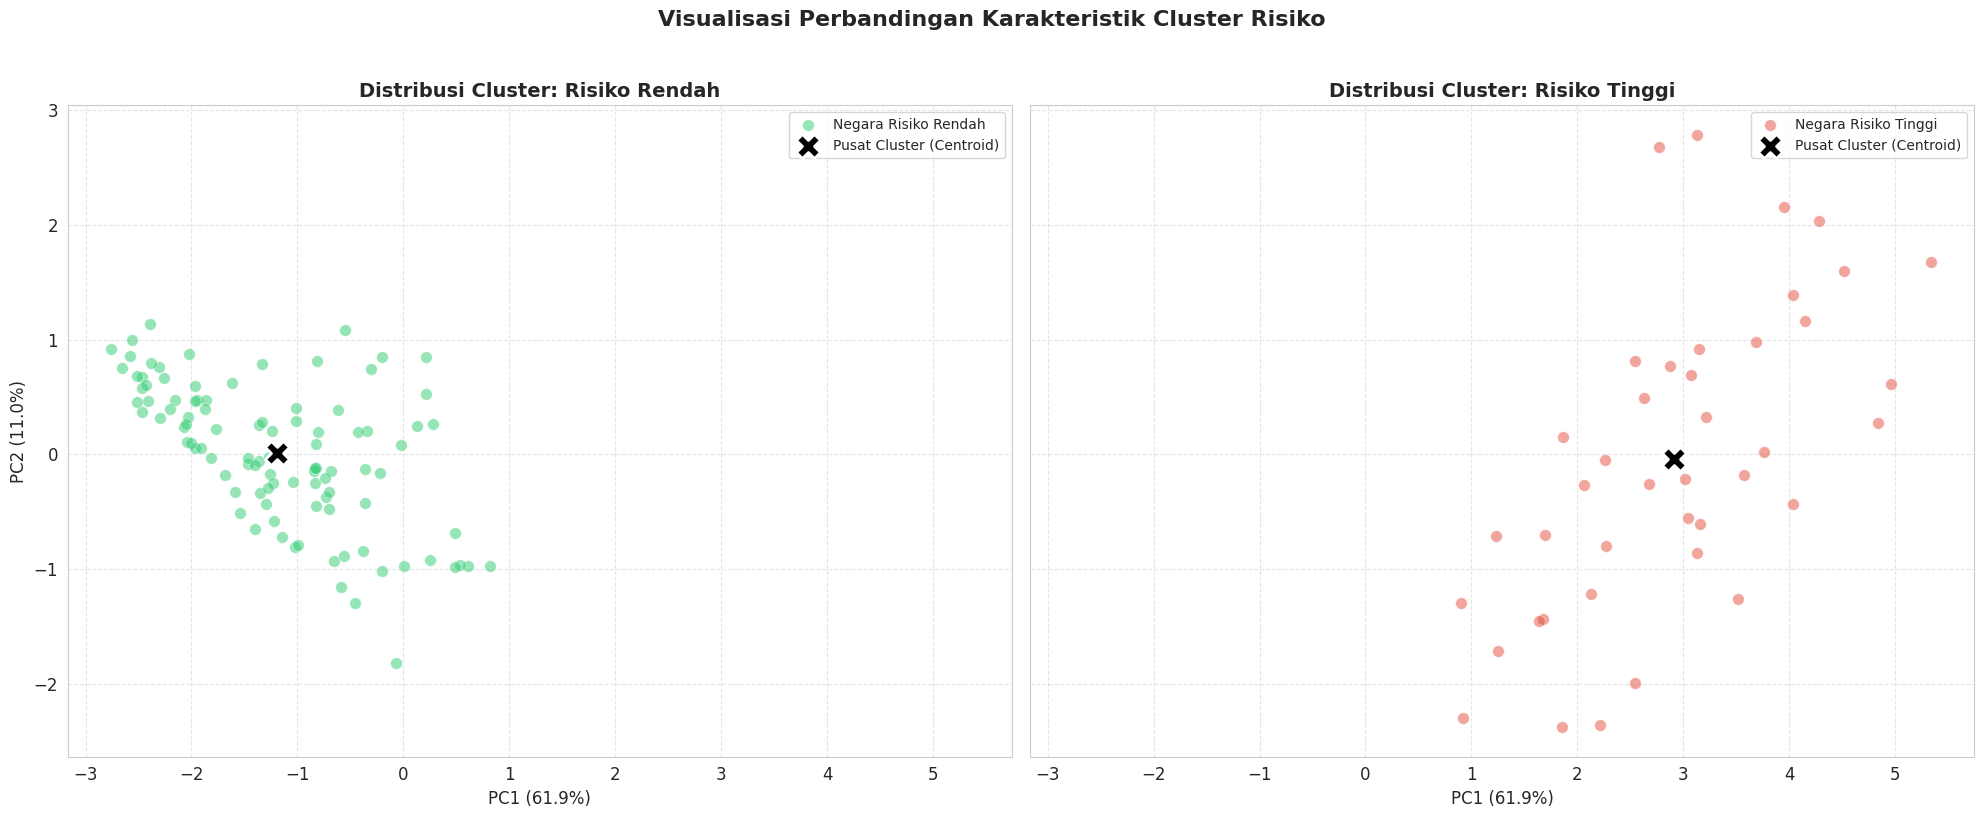


--- PENJELASAN ANALISIS CLUSTER ---
1. Densitas Kelompok: Cluster Risiko Rendah (Hijau) memiliki jumlah negara yang jauh lebih banyak dan cenderung lebih terkonsentrasi di sisi kiri (PC1 negatif), mencerminkan standar kesehatan yang lebih stabil secara global.
2. Dispersi Risiko Tinggi: Cluster Risiko Tinggi (Merah) tersebar lebih luas di sisi kanan PC1. Ini menunjukkan bahwa negara-negara dalam kelompok ini memiliki variasi beban penyakit yang sangat berbeda satu sama lain (heterogen).
3. Makna PC1: Karena PC1 menjelaskan variansi terbesar (~72%), perpisahan horizontal yang kontras antara kedua plot ini menegaskan bahwa faktor utama yang membedakan negara adalah angka harapan hidup dan mortalitas dewasa.
4. Outlier Spasial: Titik-titik yang berada jauh dari 'X' (centroid) dalam masing-masing plot adalah negara-negara transisi yang mungkin mulai membaik atau memburuk profil kesehatannya.


In [ ]:
print("=" * 70)
print("ANALISIS PERBANDINGAN CLUSTER (HISTORIS)")
print("=" * 70)

# Visualisasi Terpisah per Cluster
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)
risk_levels = ['Risiko Rendah', 'Risiko Tinggi']
risk_colors_inf = {'Risiko Rendah': '#2ecc71', 'Risiko Tinggi': '#e74c3c'}

for i, level in enumerate(risk_levels):
    ax = axes[i]
    # Plot data training untuk cluster tertentu
    mask = df_result['Risk_Level'] == level
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=risk_colors_inf[level],
               label=f'Negara {level}', alpha=0.5, s=70, edgecolors='white', linewidth=0.5)

    # Plot Centroid untuk cluster tersebut
    centroid = kmeans.cluster_centers_[sorted_clusters[i] if 'sorted_clusters' in globals() else i]
    ax.scatter(centroid[0], centroid[1], c='black', marker='X', s=300,
               label='Pusat Cluster (Centroid)', edgecolors='white', linewidth=2, zorder=11)

    ax.set_title(f'Distribusi Cluster: {level}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    if i == 0: ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Visualisasi Perbandingan Karakteristik Cluster Risiko', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n--- PENJELASAN ANALISIS CLUSTER ---")
print("1. Densitas Kelompok: Cluster Risiko Rendah (Hijau) memiliki jumlah negara yang jauh lebih banyak dan cenderung lebih terkonsentrasi di sisi kiri (PC1 negatif), mencerminkan standar kesehatan yang lebih stabil secara global.")
print("2. Dispersi Risiko Tinggi: Cluster Risiko Tinggi (Merah) tersebar lebih luas di sisi kanan PC1. Ini menunjukkan bahwa negara-negara dalam kelompok ini memiliki variasi beban penyakit yang sangat berbeda satu sama lain (heterogen).")
print("3. Makna PC1: Karena PC1 menjelaskan variansi terbesar (~72%), perpisahan horizontal yang kontras antara kedua plot ini menegaskan bahwa faktor utama yang membedakan negara adalah angka harapan hidup dan mortalitas dewasa.")
print("4. Outlier Spasial: Titik-titik yang berada jauh dari 'X' (centroid) dalam masing-masing plot adalah negara-negara transisi yang mungkin mulai membaik atau memburuk profil kesehatannya.")